In [14]:
# ============================================================================
# CELL 1: Imports and Configuration
# ============================================================================

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
from datetime import datetime
import warnings
import os
import re

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Configuration - Points to ICSA paper experiment data (not live scanner results)
CONFIG = {
    'ground_truth_path': '../experiment_data/ground_truth.json',
    'repo_metadata_files': [
        '../experiment_data/microref/logs/exp3_FILTER_repositories_filtered.jsonl',
        '../experiment_data/microref/logs/exp4_FILTER_repositories_filtered.jsonl'
    ],
    'contributor_files': [
        '../experiment_data/microref/logs/exp3_CSV_contributors.csv',
        '../experiment_data/microref/logs/exp4_CSV_contributors.csv'
    ],
    'logs_dir': '../experiment_data/paper_evidence/logs',
    'results_base_dir': '../experiment_data/paper_evidence/detection_results/',
    'output_dir': './analysis_output/',
    'paper_figures_dir': './paper_figures/',
    'paper_tables_dir': './paper_tables/',
}

# Create output directories
for dir_path in CONFIG.values():
    if isinstance(dir_path, str) and dir_path.endswith('/'):
        Path(dir_path).mkdir(exist_ok=True, parents=True)

print("✅ Libraries loaded and directories created")
print(f"📊 Analyzing ICSA paper experiment results from: {CONFIG['results_base_dir']}")


# ============================================================================
# HELPER FUNCTIONS - Data Loading
# ============================================================================

def load_ground_truth(path: str) -> Dict:
    """Load ground truth from JSON file."""
    with open(path, 'r') as f:
        return json.load(f)


def load_repo_metadata(jsonl_paths):
    """Load repository metadata from JSONL files."""
    metadata = {}
    
    if not jsonl_paths:
        return metadata
    
    for jsonl_path in jsonl_paths:
        if not os.path.exists(jsonl_path):
            print(f"⚠️  Warning: Metadata file not found: {jsonl_path}")
            continue
        
        count = 0
        
        with open(jsonl_path, 'r') as f:
            for line in f:
                if line.strip():
                    try:
                        data = json.loads(line)
                        full_name = data.get('metadata', {}).get('full_name', '')
                        html_url = data.get('metadata', {}).get('html_url', '')
                        
                        if full_name:
                            metadata[full_name] = {
                                **data.get('metadata', {}),
                                'html_url': html_url
                            }
                            count += 1
                    except json.JSONDecodeError as e:
                        print(f"⚠️  Warning: Failed to parse line: {e}")
                        continue
        
        if count > 0:
            print(f"  ✅ Loaded {count} repositories from {os.path.basename(jsonl_path)}")
    
    return metadata


def load_contributor_stats(csv_paths):
    """Load contributor statistics from CSV files."""
    if not csv_paths:
        return {'total_contributors': 0, 'unique_emails': 0, 'by_file': {}}
    
    all_emails = set()
    stats = {'by_file': {}}
    
    for csv_path in csv_paths:
        if not os.path.exists(csv_path):
            print(f"⚠️  Warning: Contributors file not found: {csv_path}")
            continue
        
        # Read CSV
        df = pd.read_csv(csv_path)
        
        # Count unique emails in this file
        emails_in_file = df['email'].dropna().unique()
        file_count = len(emails_in_file)
        
        # Add to overall set
        all_emails.update(emails_in_file)
        
        # Store per-file stats
        filename = Path(csv_path).name
        stats['by_file'][filename] = {
            'total_rows': len(df),
            'unique_emails': file_count
        }
    
    stats['total_contributors'] = len(all_emails)
    stats['unique_emails'] = len(all_emails)
    
    return stats


# Load metadata
print(f"\n📂 Loading repository metadata...")
repo_metadata = load_repo_metadata(CONFIG['repo_metadata_files'])

if repo_metadata:
    print(f"✅ Loaded metadata for {len(repo_metadata)} repositories")
else:
    print("⚠️  Running without metadata")

# Load contributor statistics
print(f"\n👥 Loading contributor statistics...")
contributor_stats = load_contributor_stats(CONFIG['contributor_files'])

if contributor_stats['total_contributors'] > 0:
    print(f"✅ Total unique contributors contacted: {contributor_stats['total_contributors']}")
    for filename, stats in contributor_stats['by_file'].items():
        print(f"   • {filename}: {stats['unique_emails']} unique emails ({stats['total_rows']} total entries)")
else:
    print("⚠️  No contributor data loaded")

✅ Libraries loaded and directories created
📊 Analyzing ICSA paper experiment results from: ../experiment_data/paper_evidence/detection_results/

📂 Loading repository metadata...
  ✅ Loaded 1606 repositories from exp3_FILTER_repositories_filtered.jsonl
  ✅ Loaded 1404 repositories from exp4_FILTER_repositories_filtered.jsonl
✅ Loaded metadata for 2767 repositories

👥 Loading contributor statistics...
✅ Total unique contributors contacted: 4082
   • exp3_CSV_contributors.csv: 2365 unique emails (2365 total entries)
   • exp4_CSV_contributors.csv: 2091 unique emails (2091 total entries)


In [15]:
# ============================================================================
# CELL 2: Load Ground Truth
# ============================================================================

print("\n" + "="*80)
print("LOADING GROUND TRUTH")
print("="*80)

ground_truth_path = Path(CONFIG['ground_truth_path'])

if not ground_truth_path.exists():
    print(f"\n⚠️  Ground truth file not found: {ground_truth_path}")
    raise FileNotFoundError(f"Required file not found: {ground_truth_path}")

ground_truth = load_ground_truth(CONFIG['ground_truth_path'])
print(f"\n✅ Loaded ground truth for {len(ground_truth)} repositories")

# Get list of patterns
sample_repo = list(ground_truth.values())[0]
PATTERNS = list(sample_repo['patterns'].keys())
print(f"✅ Tracking {len(PATTERNS)} patterns")


LOADING GROUND TRUTH

✅ Loaded ground truth for 190 repositories
✅ Tracking 9 patterns


In [16]:
# ============================================================================
# CELL 3: Ground Truth Statistics
# ============================================================================

print("\n" + "="*80)
print("GROUND TRUTH STATISTICS")
print("="*80)

pattern_counts = {pattern: 0 for pattern in PATTERNS}
for repo_data in ground_truth.values():
    for pattern, present in repo_data['patterns'].items():
        if present:
            pattern_counts[pattern] += 1

stats_df = pd.DataFrame([
    {
        'Pattern': pattern,
        'Count': count,
        'Percentage': f"{count/len(ground_truth)*100:.1f}%"
    }
    for pattern, count in sorted(pattern_counts.items(), key=lambda x: -x[1])
])

print(stats_df.to_string(index=False))


GROUND TRUTH STATISTICS
                            Pattern  Count Percentage
     Service instance per container     66      34.7%
   Single Service Instance per Host     61      32.1%
Multiple service instances per host     56      29.5%
        Service deployment platform     46      24.2%
            Service instance per VM     33      17.4%
                   Service registry     27      14.2%
                       Service mesh     21      11.1%
             3rd Party Registration     20      10.5%
      Server-side service discovery     18       9.5%


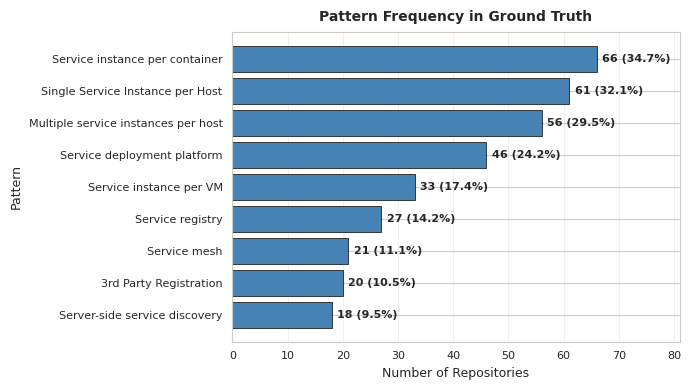

✅ Ground truth distribution visualized (double-column IEEE format, 7 inches wide)


In [17]:
# ============================================================================
# CELL 4: Visualize Ground Truth Distribution (IEEE 2-COLUMN FORMAT)
# ============================================================================

# Horizontal bar chart with count and percentage - Double column width
fig, ax = plt.subplots(figsize=(7, 4))

pattern_names = [p['Pattern'] for p in stats_df.to_dict('records')]
counts = [p['Count'] for p in stats_df.to_dict('records')]
percentages = [p['Percentage'] for p in stats_df.to_dict('records')]

# Create horizontal bars
bars = ax.barh(pattern_names, counts, color='steelblue', edgecolor='black', linewidth=0.5)

# Add count and percentage labels at the end of each bar
for i, (count, pct) in enumerate(zip(counts, percentages)):
    ax.text(count + 1, i, f'{count} ({pct})', va='center', fontsize=8, fontweight='bold')

ax.set_xlabel('Number of Repositories', fontsize=9)
ax.set_ylabel('Pattern', fontsize=9)
ax.set_title('Pattern Frequency in Ground Truth', fontsize=10, fontweight='bold', pad=8)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Set x-axis limit to ensure labels fit within bounds
max_count = max(counts)
ax.set_xlim(0, max_count + 15)  # Add space for labels

plt.tight_layout()
plt.savefig(Path(CONFIG['paper_figures_dir']) / 'ground_truth_distribution.png', 
           dpi=300, bbox_inches='tight')
plt.show()

print("✅ Ground truth distribution visualized (double-column IEEE format, 7 inches wide)")

In [18]:
# ============================================================================
# CELL 5: Helper Functions - Metrics Calculation
# ============================================================================

def extract_detections_from_report(report: Dict) -> Dict[str, bool]:
    """Extract which patterns were detected from a report."""
    detections = {}
    detected_list = report.get('summary', {}).get('detected_patterns', [])
    scanned = report.get('scanned_files_per_pattern', {}).keys()
    
    for pattern in scanned:
        detections[pattern] = pattern in detected_list
    
    return detections


def calculate_confusion_matrix_values(ground_truth: bool, detected: bool) -> Tuple[int, int, int, int]:
    """Calculate TP, FP, TN, FN for a single pattern/repo pair."""
    if ground_truth and detected:
        return (1, 0, 0, 0)  # TP
    elif not ground_truth and detected:
        return (0, 1, 0, 0)  # FP
    elif ground_truth and not detected:
        return (0, 0, 0, 1)  # FN
    else:
        return (0, 0, 1, 0)  # TN


def calculate_metrics_from_confusion(tp: int, fp: int, tn: int, fn: int) -> Dict:
    """Calculate precision, recall, accuracy, F1 from confusion matrix."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'precision': precision, 'recall': recall,
        'accuracy': accuracy, 'f1': f1
    }


def calculate_metrics_for_reports(reports: List[Dict], ground_truth: Dict, 
                                  repo_list: Optional[List[str]] = None) -> pd.DataFrame:
    """Calculate per-repository metrics for a list of reports."""
    results = []
    reports_by_repo = defaultdict(list)
    
    for report in reports:
        repo_name = report.get('summary', {}).get('repository_name', '')
        if repo_name:
            reports_by_repo[repo_name].append(report)
    
    for repo_name in (repo_list or reports_by_repo.keys()):
        if repo_name not in reports_by_repo:
            continue
        
        report = reports_by_repo[repo_name][0]
        detections = extract_detections_from_report(report)
        repo_gt = ground_truth.get(repo_name, {}).get('patterns', {})
        
        tp = fp = tn = fn = 0
        for pattern in repo_gt.keys():
            gt_value = repo_gt.get(pattern, False)
            detected = detections.get(pattern, False)
            t, f, tn_val, fn_val = calculate_confusion_matrix_values(gt_value, detected)
            tp += t
            fp += f
            tn += tn_val
            fn += fn_val
        
        metrics = calculate_metrics_from_confusion(tp, fp, tn, fn)
        metrics['repository'] = repo_name
        results.append(metrics)
    
    return pd.DataFrame(results)


def calculate_global_metrics(repo_metrics: pd.DataFrame) -> Dict:
    """Calculate aggregated metrics across all repositories."""
    total_tp = repo_metrics['tp'].sum()
    total_fp = repo_metrics['fp'].sum()
    total_tn = repo_metrics['tn'].sum()
    total_fn = repo_metrics['fn'].sum()
    
    metrics = calculate_metrics_from_confusion(total_tp, total_fp, total_tn, total_fn)
    metrics['total_repos'] = len(repo_metrics)
    metrics['total_patterns_evaluated'] = total_tp + total_fp + total_tn + total_fn
    
    return metrics


def calculate_per_pattern_metrics(reports: List[Dict], ground_truth: Dict, 
                                  patterns: List[str]) -> pd.DataFrame:
    """Calculate metrics for each pattern across all repositories."""
    pattern_results = []
    
    for pattern in patterns:
        tp = fp = tn = fn = 0
        
        for report in reports:
            repo_name = report.get('summary', {}).get('repository_name', '')
            if not repo_name or repo_name not in ground_truth:
                continue
            
            detections = extract_detections_from_report(report)
            gt_value = ground_truth[repo_name].get('patterns', {}).get(pattern, False)
            detected = detections.get(pattern, False)
            
            t, f, tn_val, fn_val = calculate_confusion_matrix_values(gt_value, detected)
            tp += t
            fp += f
            tn += tn_val
            fn += fn_val
        
        metrics = calculate_metrics_from_confusion(tp, fp, tn, fn)
        metrics['pattern'] = pattern
        pattern_results.append(metrics)
    
    return pd.DataFrame(pattern_results)


print("✅ Metrics calculation functions defined")

✅ Metrics calculation functions defined


In [19]:
# ============================================================================
# CELL 5.5: Convert All Logs to JSON Reports (With Smart Matching)
# ============================================================================

import os
import json
import re
from pathlib import Path
from collections import defaultdict

def extract_repo_name_from_path(repo_path: str) -> str:
    """
    Extract repository name from file path.
    Example: /home/user/Projects/sample-repositories/MiniSearch → MiniSearch
    """
    path = Path(repo_path)
    return path.name


def match_to_full_repo_name(folder_name: str, ground_truth: dict, repo_metadata: dict) -> str:
    """
    Match a folder name (e.g., 'MiniSearch') to full repo name (e.g., 'felladrin/MiniSearch').
    
    Args:
        folder_name: Just the folder name (e.g., 'MiniSearch')
        ground_truth: Ground truth dictionary with full repo names
        repo_metadata: Repository metadata dictionary
    
    Returns:
        Full repository name or folder name if no match found
    """
    folder_lower = folder_name.lower()
    
    # Try exact match first
    if folder_name in ground_truth:
        return folder_name
    
    # Try to find a repo that ends with this folder name
    # e.g., 'MiniSearch' → 'felladrin/MiniSearch'
    for full_name in ground_truth.keys():
        if '/' in full_name:
            _, repo_part = full_name.split('/', 1)
            if repo_part.lower() == folder_lower:
                return full_name
    
    # Try repo_metadata as well
    for full_name in repo_metadata.keys():
        if '/' in full_name:
            _, repo_part = full_name.split('/', 1)
            if repo_part.lower() == folder_lower:
                return full_name
    
    # No match found, return folder name
    return folder_name


def parse_operations_log(log_path: Path) -> dict:
    """
    Parse operations log to extract repository information.
    
    Returns:
        dict with 'repository_name' and 'repository_path'
    """
    repo_info = {
        'repository_name': 'unknown',
        'repository_path': None
    }
    
    with open(log_path, 'r') as f:
        for line in f:
            # Look for "Target: /path/to/repo"
            if 'Target:' in line and 'scanner.py' in line:
                # Extract path after "Target: "
                match = re.search(r'Target:\s+(.+)$', line)
                if match:
                    repo_path = match.group(1).strip()
                    repo_info['repository_path'] = repo_path
                    repo_info['repository_name'] = extract_repo_name_from_path(repo_path)
                    break
    
    return repo_info


def find_matching_operations_log(detection_log: Path, logs_dir: Path) -> Path:
    """
    Find the matching operations log for a detection log.
    They share the same timestamp: detection_TIMESTAMP.log ↔ operations_TIMESTAMP.log
    """
    # Extract timestamp from detection log filename
    # Format: detection_YYYYMMDD_HHMMSS.log
    parts = detection_log.stem.split('_')
    if len(parts) >= 3:
        timestamp = '_'.join(parts[1:])  # Get YYYYMMDD_HHMMSS
        operations_log = logs_dir / f"operations_{timestamp}.log"
        if operations_log.exists():
            return operations_log
    
    return None


def parse_detection_log(log_path: Path, repo_name: str = 'unknown') -> dict:
    """
    Parse detection log file and extract key information.
    
    Args:
        log_path: Path to detection log file
        repo_name: Repository name from operations log
    """
    session_info = {}
    pattern_results = {}
    
    
    with open(log_path, 'r') as f:
        for line in f:
            try:
                entry = json.loads(line.strip())
                event = entry.get('event', '')
                
                # Session start - get configuration
                if event == 'session_start':
                    session_info = {
                        'run_id': entry.get('run_id', ''),
                        'timestamp': entry.get('timestamp', ''),
                        'configuration': entry.get('configuration', {}),
                    }
                
                # Pattern analysis start
                elif event == 'pattern_analysis_start':
                    pattern = entry.get('pattern')
                    if pattern:
                        pattern_results[pattern] = {
                            'candidate_files': entry.get('candidate_files', 0),
                            'scanned_files': [],
                            'detected': False,
                            'evidence_count': 0
                        }
                
                # File scored - track which files were analyzed
                elif event == 'file_scored':
                    pattern = entry.get('pattern')
                    file_path = entry.get('file')
                    if pattern and pattern in pattern_results and file_path:
                        if file_path not in pattern_results[pattern]['scanned_files']:
                            pattern_results[pattern]['scanned_files'].append(file_path)
                
                # Investigation phase complete - track analyzed files
                elif event == 'investigation_phase_complete':
                    pattern = entry.get('pattern')
                    files_analyzed = entry.get('files_analyzed', 0)
                    if pattern and pattern in pattern_results:
                        pattern_results[pattern]['files_analyzed'] = files_analyzed
                
                # Pattern analysis complete/end - FINAL DETECTION STATUS
                elif event in ['pattern_analysis_complete', 'pattern_analysis_end']:
                    pattern = entry.get('pattern')
                    if pattern and pattern in pattern_results:
                        detected = entry.get('detected', False)
                        evidence_count = entry.get('evidence_count', 0)
                        confidence = entry.get('confidence', 0)
                        
                        pattern_results[pattern].update({
                            'detected': detected,
                            'evidence_count': evidence_count,
                            'confidence': confidence
                        })
                
                # Scan complete
                elif event == 'scan_complete':
                    session_info['scan_summary'] = entry.get('summary', {})
                    
            except json.JSONDecodeError:
                continue
    
    # Build report structure
    if not session_info:
        return None
    
    config = session_info.get('configuration', {})
    experiment = config.get('experiment', {})
    thresholds = config.get('thresholds', {})
    scan_summary = session_info.get('scan_summary', {})
    
    # Build detected_patterns list from pattern_results
    detected_patterns = [
        pattern for pattern, data in pattern_results.items()
        if data.get('detected', False)
    ]
    
    # Build patterns dict (pattern_name -> detected bool)
    patterns_dict = {
        pattern: data.get('detected', False)
        for pattern, data in pattern_results.items()
    }
    
    # Build scanned_files_per_pattern dict
    scanned_files_dict = {
        pattern: data.get('scanned_files', [])
        for pattern, data in pattern_results.items()
    }
    
    report = {
        "summary": {
            "repository_name": repo_name,
            "detected_patterns": detected_patterns,
            "total_patterns_scanned": len(pattern_results),
            "timestamp": session_info.get('timestamp', ''),
            "run_id": session_info.get('run_id', '')
        },
        "patterns": patterns_dict,
        "scanned_files_per_pattern": scanned_files_dict,
        "_metadata": {
            "experiment": experiment,
            "reproducibility": {
                "configuration": {
                    "thresholds": thresholds,
                    "weight_scheme": config.get('weight_scheme', 'balanced'),
                    "random_seed": config.get('reproducibility', {}).get('random_seed')
                }
            },
            "models": config.get('models', {}),
            "priority_weights": config.get('priority_weights', {}),
            "source_log": str(log_path.name)
        }
    }
    
    return report


# ============================================================================
# CONVERT LOGS TO JSON REPORTS
# ============================================================================

print("\n" + "="*80)
print("CONVERTING LOGS TO JSON REPORTS")
print("="*80)

logs_dir = Path(CONFIG.get('logs_dir', './logs'))
output_dir = Path(CONFIG['results_base_dir'])

print(f"Source: {logs_dir}")
print(f"Target: {output_dir}\n")

# Load ground truth and metadata for matching
print("Loading ground truth and metadata for repository name matching...")
try:
    ground_truth = load_ground_truth(CONFIG['ground_truth_path'])
    print(f"✅ Loaded ground truth: {len(ground_truth)} repositories")
except Exception as e:
    print(f"⚠️  Could not load ground truth: {e}")
    ground_truth = {}

# Find all detection logs
detection_logs = list(logs_dir.glob('detection_*.log'))

if not detection_logs:
    print(f"⚠️  No detection_*.log files found in {logs_dir}")
else:
    print(f"Found {len(detection_logs)} detection log files\n")
    
    stats = {
        'total': len(detection_logs),
        'converted': 0,
        'errors': 0,
        'by_phase': defaultdict(int),
        'matched': 0,
        'unmatched': 0
    }
    
    for detection_log in detection_logs:
        try:
            # Find matching operations log
            operations_log = find_matching_operations_log(detection_log, logs_dir)
            
            # Extract folder name from operations log
            folder_name = 'unknown'
            if operations_log and operations_log.exists():
                repo_info = parse_operations_log(operations_log)
                folder_name = repo_info['repository_name']
                print(f"📄 {detection_log.name}")
                print(f"   + {operations_log.name}")
                print(f"   Folder name: {folder_name}")
            else:
                print(f"⚠️  {detection_log.name}")
                print(f"   → No matching operations log found")
            
            # Match folder name to full repository name
            full_repo_name = match_to_full_repo_name(folder_name, ground_truth, repo_metadata)
            
            if full_repo_name != folder_name:
                print(f"   ✅ Matched: {folder_name} → {full_repo_name}")
                stats['matched'] += 1
            else:
                print(f"   ⚠️  No match found for '{folder_name}' in ground truth")
                stats['unmatched'] += 1
            
            # Parse detection log with full repository name
            report = parse_detection_log(detection_log, full_repo_name)
            
            if report is None:
                print(f"   ❌ No valid session data\n")
                stats['errors'] += 1
                continue
            
            # Determine output location from phase
            phase = report['_metadata']['experiment'].get('phase', 'unknown')
            
            # Generate filename
            run_id = report['summary']['run_id']
            safe_repo = full_repo_name.replace('/', '_').replace(' ', '_')
            filename = f"{safe_repo}_{run_id[:8]}.json"

            output_path = output_dir / filename  # Make it a Path object

            # Save JSON
            with open(output_path, 'w') as f:
                json.dump(report, f, indent=2)

            # Update stats
            stats['converted'] += 1
            stats['by_phase'][phase] += 1

            print(f"   💾 Saved: {output_path.relative_to(output_dir)}\n")
            
        except Exception as e:
            print(f"❌ Error processing {detection_log.name}: {e}\n")
            import traceback
            traceback.print_exc()
            stats['errors'] += 1
            continue
    
    # Print summary
    print("="*80)
    print("CONVERSION SUMMARY")
    print("="*80)
    print(f"Total logs: {stats['total']}")
    print(f"Converted: {stats['converted']}")
    print(f"Matched to full name: {stats['matched']}")
    print(f"Unmatched (using folder name): {stats['unmatched']}")
    print(f"Errors: {stats['errors']}")
    
    print("="*80)
    print("\n✅ Conversion complete! JSON reports ready for analysis.")


CONVERTING LOGS TO JSON REPORTS
Source: ../experiment_data/paper_evidence/logs
Target: ../experiment_data/paper_evidence/detection_results

Loading ground truth and metadata for repository name matching...
✅ Loaded ground truth: 190 repositories
Found 192 detection log files

📄 detection_20251030_182841.log
   + operations_20251030_182841.log
   Folder name: online-go.com
   ✅ Matched: online-go.com → online-go/online-go.com
   💾 Saved: online-go_online-go.com_0322cd22.json

📄 detection_20251031_045107.log
   + operations_20251031_045107.log
   Folder name: scala-debug-adapter
   ✅ Matched: scala-debug-adapter → scalacenter/scala-debug-adapter
   💾 Saved: scalacenter_scala-debug-adapter_a669f873.json

📄 detection_20251029_201644.log
   + operations_20251029_201644.log
   Folder name: globus-compute
   ✅ Matched: globus-compute → globus/globus-compute
   💾 Saved: globus_globus-compute_36f0dd28.json

📄 detection_20251030_205511.log
   + operations_20251030_205511.log
   Folder name: boo

In [20]:
# ============================================================================
# CELL 6: Load Reports Function
# ============================================================================

def load_reports_by_criteria(base_dir: str, repo_filter: Optional[List[str]] = None, 
                             verbose: bool = False) -> List[Dict]:
    """Load detection reports from JSON files."""
    reports = []
    search_dir = Path(base_dir)
    
    if not search_dir.exists():
        print(f"⚠️  Directory not found: {search_dir}")
        return []
    
    json_files = list(search_dir.glob('*.json'))
    
    if not json_files:
        print(f"⚠️  No JSON reports found in {search_dir}")
        return []
    
    print(f"📂 Loading from: {search_dir}")
    print(f"   Found {len(json_files)} JSON files")
    
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                report = json.load(f)
            
            repo_name = report.get('summary', {}).get('repository_name', '')
            
            if verbose:
                print(f"\n   📄 {json_file.name}: Repo: {repo_name}")
            
            if repo_filter is not None and repo_name not in repo_filter:
                if verbose:
                    print(f"      ❌ Repository not in filter list")
                continue
            
            if verbose:
                print(f"      ✅ Matches all filters!")
            reports.append(report)
            
        except Exception as e:
            print(f"⚠️  Error loading {json_file.name}: {e}")
            continue
    
    if reports:
        repos = set(r.get('summary', {}).get('repository_name', 'unknown') for r in reports)
        print(f"\n✅ Loaded {len(reports)} reports from {len(repos)} repositories")
    else:
        print(f"\n❌ No reports matched the filter criteria")
    
    return reports


print("✅ Report loading function defined")

✅ Report loading function defined


In [21]:
# ============================================================================
# CELL 7: Analyze All Reports
# ============================================================================

print("\n" + "="*80)
print("ANALYZING ALL REPORTS")
print("="*80)

# Load all reports
all_reports = load_reports_by_criteria(CONFIG['results_base_dir'])

if len(all_reports) == 0:
    print("⚠️  No reports found.")
    print("   Run the scanner on repositories first!")
else:
    # Calculate metrics
    repo_metrics = calculate_metrics_for_reports(all_reports, ground_truth)
    global_metrics = calculate_global_metrics(repo_metrics)
    pattern_metrics = calculate_per_pattern_metrics(all_reports, ground_truth, PATTERNS)
    
    print("\n📊 Overall Performance:")
    print(f"   Repositories: {global_metrics['total_repos']}")
    print(f"   Precision: {global_metrics['precision']:.4f}")
    print(f"   Recall: {global_metrics['recall']:.4f}")
    print(f"   Accuracy: {global_metrics['accuracy']:.4f}")
    print(f"   F1-Score: {global_metrics['f1']:.4f}")
    print(f"   TP: {global_metrics['tp']}, FP: {global_metrics['fp']}")
    print(f"   FN: {global_metrics['fn']}, TN: {global_metrics['tn']}")
    
    # Save results
    results_df = pd.DataFrame([{
        'Metric': metric,
        'Value': value
    } for metric, value in global_metrics.items()])
    
    results_df.to_csv(Path(CONFIG['paper_tables_dir']) / 'overall_metrics.csv', index=False)
    print(f"\n✅ Results saved to {CONFIG['paper_tables_dir']}")


ANALYZING ALL REPORTS
📂 Loading from: ../experiment_data/paper_evidence/detection_results
   Found 192 JSON files

✅ Loaded 192 reports from 192 repositories

📊 Overall Performance:
   Repositories: 192
   Precision: 0.4957
   Recall: 0.3276
   Accuracy: 0.7953
   F1-Score: 0.3945
   TP: 114, FP: 116
   FN: 234, TN: 1246

✅ Results saved to ./paper_tables/



PER-PATTERN ANALYSIS

📊 Per-Pattern Performance with Ground Truth Prevalence:
                            pattern  precision  recall  accuracy     f1  prevalence  prevalence_pct
             3rd Party Registration     0.3333  0.0500    0.8895 0.0870          20         10.5000
Multiple service instances per host     0.4375  0.5000    0.6632 0.4667          56         29.5000
      Server-side service discovery     0.2667  0.2222    0.8684 0.2424          18          9.5000
        Service deployment platform     0.4000  0.4348    0.7053 0.4167          46         24.2000
     Service instance per container     0.6812  0.7121    0.7842 0.6963          66         34.7000
            Service instance per VM     0.7500  0.0909    0.8368 0.1622          33         17.4000
                       Service mesh     0.4000  0.0952    0.8842 0.1538          21         11.1000
                   Service registry     0.2857  0.0741    0.8421 0.1176          27         14.2000
   Single Service Ins

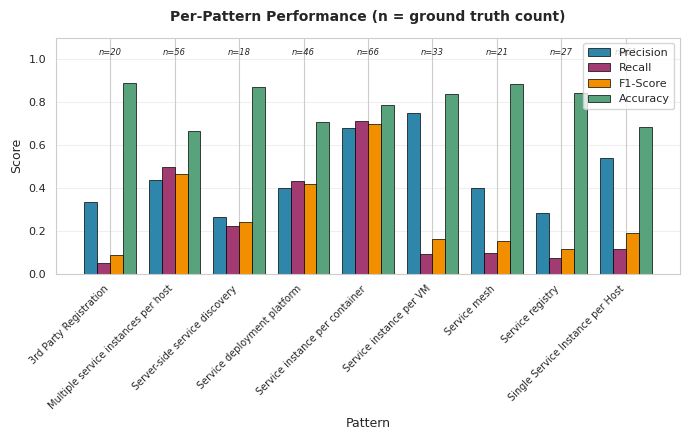

✅ Per-pattern analysis complete (with ground truth prevalence)


In [22]:
# ============================================================================
# CELL 8: Per-Pattern Analysis (IEEE 2-COLUMN FORMAT)
# ============================================================================

if len(all_reports) > 0:
    print("\n" + "="*80)
    print("PER-PATTERN ANALYSIS")
    print("="*80)

    # --- Compute Accuracy if not already present ---
    if 'accuracy' not in pattern_metrics.columns:
        if all(col in pattern_metrics.columns for col in ['tp', 'tn', 'fp', 'fn']):
            pattern_metrics['accuracy'] = (
                (pattern_metrics['tp'] + pattern_metrics['tn']) /
                (pattern_metrics['tp'] + pattern_metrics['tn'] + pattern_metrics['fp'] + pattern_metrics['fn'])
            )
        else:
            pattern_metrics['accuracy'] = pattern_metrics['tp'] / (
                pattern_metrics['tp'] + pattern_metrics['fp'] + pattern_metrics['fn']
            )

    # --- ADD PREVALENCE FROM GROUND TRUTH ---
    pattern_metrics['prevalence'] = pattern_metrics['pattern'].map(pattern_counts)
    pattern_metrics['prevalence_pct'] = (pattern_metrics['prevalence'] / len(ground_truth) * 100).round(1)

    print("\n📊 Per-Pattern Performance with Ground Truth Prevalence:")
    print(pattern_metrics[['pattern', 'precision', 'recall', 'accuracy', 'f1', 'prevalence', 'prevalence_pct']].to_string(index=False))

    # Save per-pattern results
    pattern_metrics.to_csv(Path(CONFIG['paper_tables_dir']) / 'per_pattern_metrics.csv', index=False)

    # --- Visualization with prevalence annotations ---
    fig, ax = plt.subplots(figsize=(7, 4.5))

    x = np.arange(len(pattern_metrics))
    width = 0.2

    ax.bar(x - 1.5*width, pattern_metrics['precision'], width, label='Precision', color='#2E86AB', edgecolor='black', linewidth=0.5)
    ax.bar(x - 0.5*width, pattern_metrics['recall'], width, label='Recall', color='#A23B72', edgecolor='black', linewidth=0.5)
    ax.bar(x + 0.5*width, pattern_metrics['f1'], width, label='F1-Score', color='#F18F01', edgecolor='black', linewidth=0.5)
    ax.bar(x + 1.5*width, pattern_metrics['accuracy'], width, label='Accuracy', color='#58A27C', edgecolor='black', linewidth=0.5)

    # Add prevalence annotations on top
    for i, (idx, row) in enumerate(pattern_metrics.iterrows()):
        ax.text(i, 1.02, f"n={int(row['prevalence'])}", ha='center', fontsize=6, style='italic')

    ax.set_xlabel('Pattern', fontsize=9)
    ax.set_ylabel('Score', fontsize=9)
    ax.set_title('Per-Pattern Performance (n = ground truth count)', fontsize=10, fontweight='bold', pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(pattern_metrics['pattern'], rotation=45, ha='right', fontsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])  # Extra space for annotations

    plt.tight_layout()
    plt.savefig(Path(CONFIG['paper_figures_dir']) / 'per_pattern_performance.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Per-pattern analysis complete (with ground truth prevalence)")



METRIC EVOLUTION OVER TIME

📊 Analyzing evolution of metrics across 192 repositories
   Calculating metrics every 5 repositories...

📈 Evolution Summary:
 num_repos  precision  recall  accuracy     f1
         5     0.6667  0.3077    0.7556 0.4211
        10     0.7333  0.2895    0.6556 0.4151
        15     0.6875  0.2500    0.7185 0.3667
        20     0.6957  0.3200    0.7722 0.4384
        25     0.6857  0.3692    0.7689 0.4800
        30     0.6341  0.3768    0.7852 0.4727
        35     0.5778  0.3514    0.7873 0.4370
        40     0.5800  0.3494    0.7917 0.4361
        45     0.6038  0.3556    0.8049 0.4476
        50     0.6102  0.3711    0.8133 0.4615
        55     0.6364  0.3784    0.8121 0.4746
        60     0.6081  0.3782    0.8093 0.4663
        65     0.5844  0.3750    0.8171 0.4569
        70     0.5610  0.3407    0.8016 0.4240
        75     0.5506  0.3525    0.8074 0.4298
        80     0.5437  0.3758    0.8056 0.4444
        85     0.5357  0.3822    0.8052 0.4461

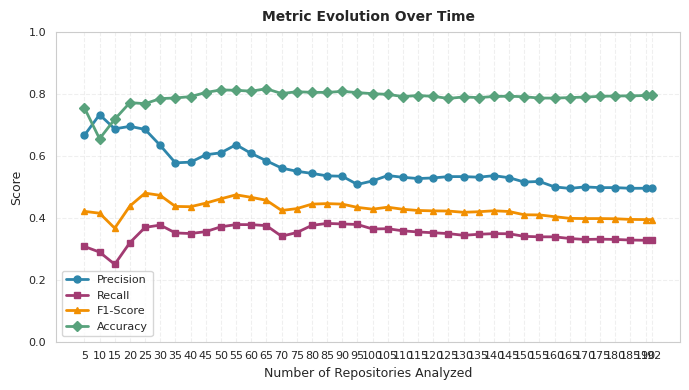


✅ Saved: metric_evolution.png (double-column IEEE format)

--------------------------------------------------------------------------------
METRIC STABILITY ANALYSIS
--------------------------------------------------------------------------------
   Precision   : 0.4957 (stable, Δ=+0.0001)
   Recall      : 0.3276 (stable, Δ=-0.0009)
   Accuracy    : 0.7953 (stable, Δ=+0.0013)
   F1          : 0.3945 (stable, Δ=-0.0006)

✅ Metric evolution analysis complete


In [23]:
# ============================================================================
# CELL 8.5: Metric Evolution Over Time (Every 5 Repositories)
# ============================================================================

if len(all_reports) > 0:
    print("\n" + "="*80)
    print("METRIC EVOLUTION OVER TIME")
    print("="*80)
    
    # Sort reports by timestamp chronologically
    sorted_reports = sorted(all_reports, key=lambda x: x['summary']['timestamp'])
    
    print(f"\n📊 Analyzing evolution of metrics across {len(sorted_reports)} repositories")
    print(f"   Calculating metrics every 5 repositories...")
    
    # Calculate metrics at different intervals (every 5 repos)
    evolution_data = []
    
    for i in range(5, len(sorted_reports) + 1, 5):
        # Get reports up to this point
        reports_subset = sorted_reports[:i]
        
        # Calculate metrics for this subset
        repo_metrics_subset = calculate_metrics_for_reports(reports_subset, ground_truth)
        global_metrics_subset = calculate_global_metrics(repo_metrics_subset)
        
        evolution_data.append({
            'num_repos': i,
            'precision': global_metrics_subset['precision'],
            'recall': global_metrics_subset['recall'],
            'accuracy': global_metrics_subset['accuracy'],
            'f1': global_metrics_subset['f1'],
            'tp': global_metrics_subset['tp'],
            'fp': global_metrics_subset['fp'],
            'fn': global_metrics_subset['fn'],
            'tn': global_metrics_subset['tn']
        })
    
    # If we have remaining repos (not divisible by 5), add the final total
    if len(sorted_reports) % 5 != 0:
        repo_metrics_all = calculate_metrics_for_reports(sorted_reports, ground_truth)
        global_metrics_all = calculate_global_metrics(repo_metrics_all)
        
        evolution_data.append({
            'num_repos': len(sorted_reports),
            'precision': global_metrics_all['precision'],
            'recall': global_metrics_all['recall'],
            'accuracy': global_metrics_all['accuracy'],
            'f1': global_metrics_all['f1'],
            'tp': global_metrics_all['tp'],
            'fp': global_metrics_all['fp'],
            'fn': global_metrics_all['fn'],
            'tn': global_metrics_all['tn']
        })
    
    evolution_df = pd.DataFrame(evolution_data)
    
    print(f"\n📈 Evolution Summary:")
    print(evolution_df[['num_repos', 'precision', 'recall', 'accuracy', 'f1']].to_string(index=False))
    
    # Save evolution data
    evolution_df.to_csv(Path(CONFIG['paper_tables_dir']) / 'metric_evolution.csv', index=False)
    print(f"\n✅ Saved: {CONFIG['paper_tables_dir']}metric_evolution.csv")
    
    # ============================================================================
    # VISUALIZATION - Metric Evolution Over Time (IEEE Double-Column)
    # ============================================================================
    
    fig, ax = plt.subplots(figsize=(7, 4))
    
    ax.plot(evolution_df['num_repos'], evolution_df['precision'], 
            marker='o', label='Precision', linewidth=2, markersize=5, color='#2E86AB')
    ax.plot(evolution_df['num_repos'], evolution_df['recall'], 
            marker='s', label='Recall', linewidth=2, markersize=5, color='#A23B72')
    ax.plot(evolution_df['num_repos'], evolution_df['f1'], 
            marker='^', label='F1-Score', linewidth=2, markersize=5, color='#F18F01')
    ax.plot(evolution_df['num_repos'], evolution_df['accuracy'], 
            marker='D', label='Accuracy', linewidth=2, markersize=5, color='#58A27C')
    
    ax.set_xlabel('Number of Repositories Analyzed', fontsize=9)
    ax.set_ylabel('Score', fontsize=9)
    ax.set_title('Metric Evolution Over Time', fontsize=10, fontweight='bold', pad=8)
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=8, loc='best')
    ax.grid(axis='both', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.0])
    
    # Add markers at every 5 repos on x-axis
    ax.set_xticks(evolution_df['num_repos'])
    
    plt.tight_layout()
    plt.savefig(Path(CONFIG['paper_figures_dir']) / 'metric_evolution.png', 
               dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Saved: metric_evolution.png (double-column IEEE format)")
    
    # ============================================================================
    # Additional Analysis: Stability
    # ============================================================================
    
    if len(evolution_df) >= 3:
        print("\n" + "-"*80)
        print("METRIC STABILITY ANALYSIS")
        print("-"*80)
        
        # Calculate change in last 3 intervals
        recent_data = evolution_df.tail(3)
        
        for metric in ['precision', 'recall', 'accuracy', 'f1']:
            values = recent_data[metric].values
            if len(values) >= 2:
                change = values[-1] - values[0]
                trend = "increasing" if change > 0.01 else ("decreasing" if change < -0.01 else "stable")
                print(f"   {metric.capitalize():12s}: {values[-1]:.4f} ({trend}, Δ={change:+.4f})")
    
    print("\n✅ Metric evolution analysis complete")


In [24]:
# ============================================================================
# DEBUG CELL - Run this BEFORE Cell 8.6 to diagnose issues
# ============================================================================

print("="*80)
print("DEBUGGING CELL 8.6")
print("="*80)

# Check 1: Does all_reports exist and have data?
try:
    print(f"\n✅ all_reports exists: {len(all_reports)} reports found")
    if len(all_reports) == 0:
        print("   ❌ ERROR: all_reports is empty! You need to run Cell 7 first.")
    else:
        print(f"   Sample report keys: {list(all_reports[0].keys())}")
except NameError:
    print("\n❌ ERROR: 'all_reports' does not exist!")
    print("   Solution: Run Cell 7 (Analyze All Reports) first")

# Check 2: Do we have run_id to repo mapping?
try:
    run_id_to_repo = {}
    for report in all_reports:
        run_id = report['summary']['run_id']
        repo_name = report['summary']['repository_name']
        run_id_to_repo[run_id] = repo_name
    print(f"\n✅ Can map {len(run_id_to_repo)} run_ids to repositories")
except Exception as e:
    print(f"\n❌ ERROR mapping run_ids: {e}")

# Check 3: Do detection logs exist?
try:
    logs_dir = Path(CONFIG['logs_dir'])
    detection_logs = list(logs_dir.glob('detection_*.log'))
    print(f"\n✅ Found {len(detection_logs)} detection log files")

    if detection_logs:
        print(f"   Latest: {detection_logs[-1].name}")
except Exception as e:
    print(f"\n❌ ERROR finding logs: {e}")

# Check 4: Do logs contain 'file_investigated' events?
if detection_logs:
    sample_log = detection_logs[0]
    has_file_investigated = False

    print(f"\n   Checking {sample_log.name} for 'file_investigated' events...")

    with open(sample_log, 'r') as f:
        for i, line in enumerate(f):
            try:
                data = json.loads(line.strip())
                if data.get('event') == 'file_investigated':
                    has_file_investigated = True
                    print(f"   ✅ Found 'file_investigated' event at line {i+1}")
                    break
            except:
                continue

        if not has_file_investigated:
            print("   ⚠️  WARNING: No 'file_investigated' events found in sample log")
            print("      Cell 8.6 may not have data to visualize")
            print("      These events are logged when the LLM investigates files")

# Check 5: Check if repo_investigated_files will have data
print("\n" + "="*80)
print("EXPECTED OUTPUT FROM CELL 8.6:")
print("="*80)

if len(all_reports) > 0 and detection_logs:
    print("✅ Cell 8.6 should run (but may have no visualizations if no file_investigated events)")
else:
    print("❌ Cell 8.6 will NOT run - missing prerequisites")

print("\n" + "="*80)


DEBUGGING CELL 8.6

✅ all_reports exists: 192 reports found
   Sample report keys: ['summary', 'patterns', 'scanned_files_per_pattern', '_metadata']

✅ Can map 192 run_ids to repositories

✅ Found 192 detection log files
   Latest: detection_20251027_201941.log

   Checking detection_20251030_182841.log for 'file_investigated' events...
   ⚠️  WARNING: No 'file_investigated' events found in sample log
      Cell 8.6 may not have data to visualize
      These events are logged when the LLM investigates files

EXPECTED OUTPUT FROM CELL 8.6:
✅ Cell 8.6 should run (but may have no visualizations if no file_investigated events)




FILE SCORING AND ANALYSIS STATISTICS

📊 Parsing detection logs to extract file-level data...
   Mapped 192 runs to repositories
   Processing 192 detection log files...
   ✅ Processed 192 runs successfully
   ✅ Total repositories with file data: 190

--------------------------------------------------------------------------------
OVERALL FILE STATISTICS
--------------------------------------------------------------------------------

📊 Summary:
   Total files scored (candidates):     118,177
   Total files analyzed (investigated): 18,892
   Total evidence files found:          991

   Analysis rate:  15.99% of scored files were analyzed
   Evidence rate:  5.25% of analyzed files became evidence
   Precision:      0.84% of scored files became evidence

FILE EXTENSION AND FILENAME ANALYSIS (FROM SCORED FILES)

✅ Saved: paper_tables/pattern_file_extensions.csv
✅ Saved: paper_tables/pattern_top_filenames_detected.csv

GENERATING VISUALIZATIONS

📊 Creating file extension visualizations...


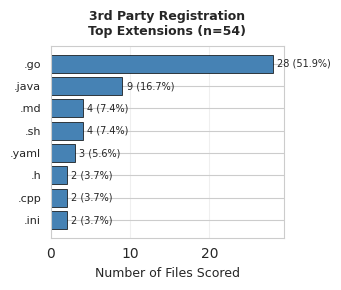

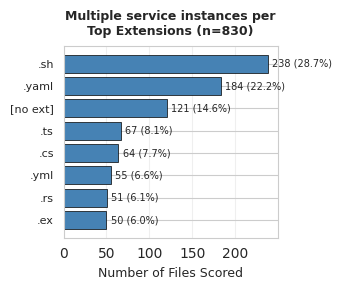

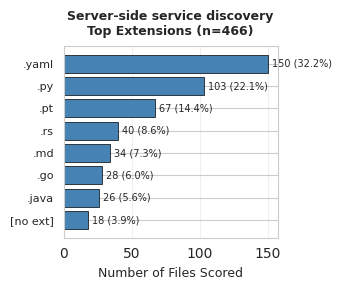

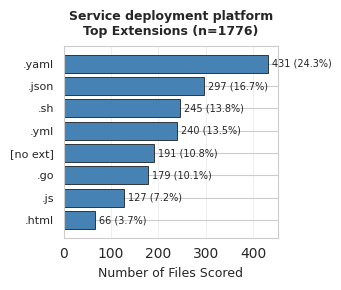

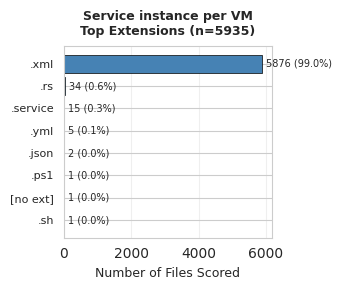

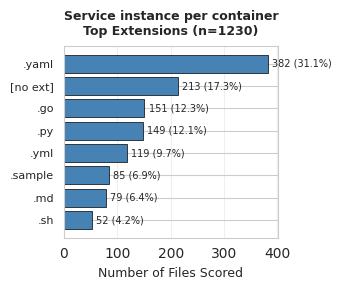

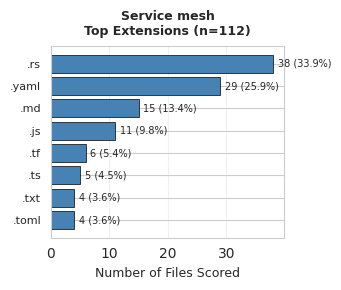

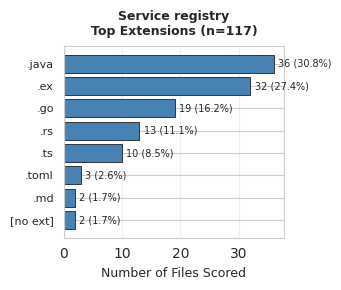

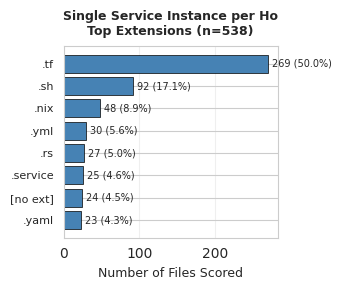

✅ Created 9 extension charts

📊 Creating filename visualizations...


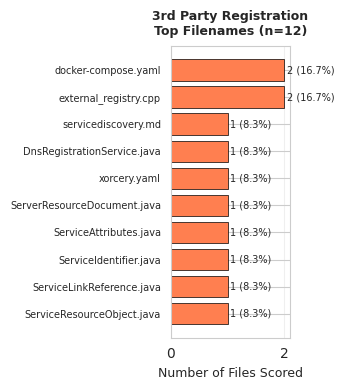

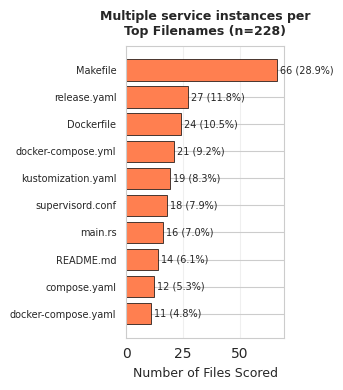

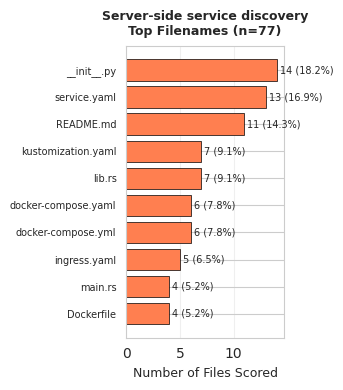

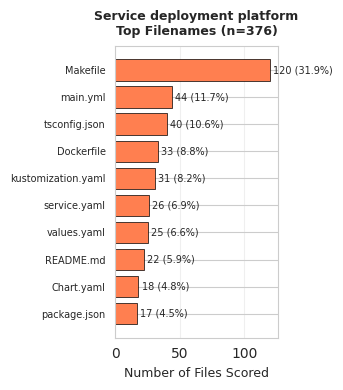

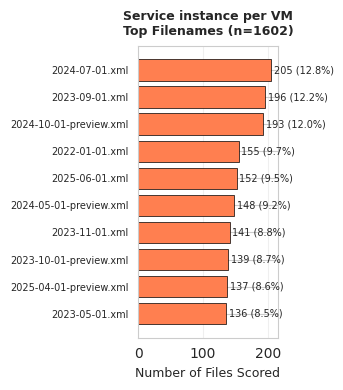

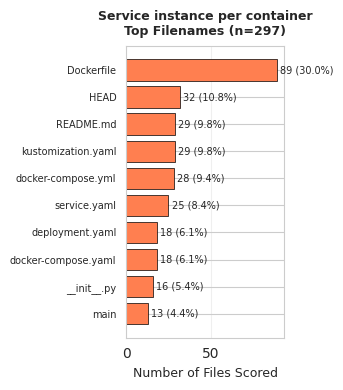

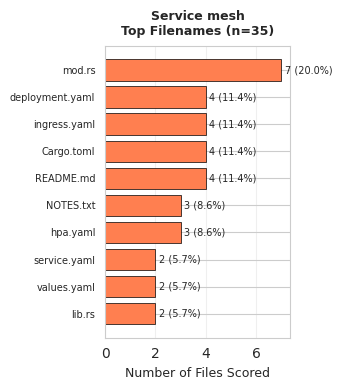

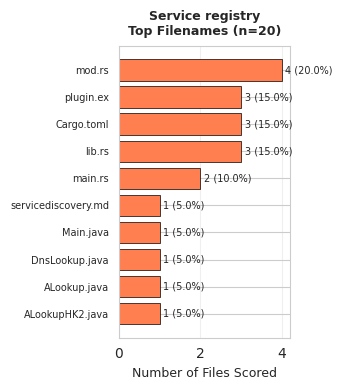

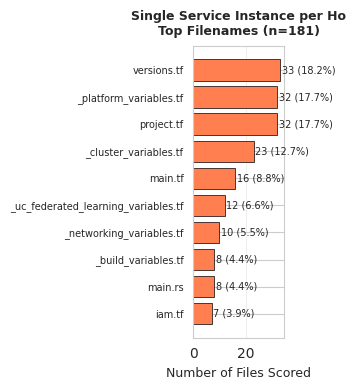

✅ Created 9 filename charts


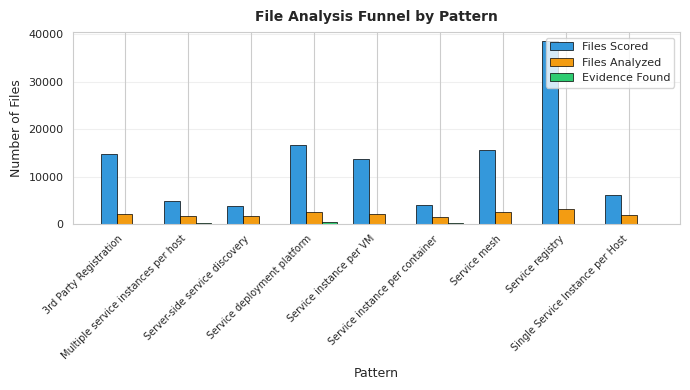


FILE ANALYSIS COMPLETE

📊 CSV Tables: 3 files
📈 Visualizations: ~19 files
   - File extension charts per pattern (when detected)
   - Filename charts per pattern (when detected)
   - File analysis funnel

✅ All files saved to paper_figures/ and paper_tables/


In [25]:
# ============================================================================
# CELL 8.6: File Analysis - Files Scored vs Analyzed per Repository/Pattern
# ============================================================================

if len(all_reports) > 0:
    from collections import Counter
    print("\n" + "="*80)
    print("FILE SCORING AND ANALYSIS STATISTICS")
    print("="*80)

    print("\n📊 Parsing detection logs to extract file-level data...")

    # Step 1: Build mapping from run_id to repository name
    run_id_to_repo = {}
    for report in all_reports:
        run_id = report['summary']['run_id']
        repo_name = report['summary']['repository_name']
        run_id_to_repo[run_id] = repo_name

    print(f"   Mapped {len(run_id_to_repo)} runs to repositories")

    # Step 2: Parse all detection logs
    logs_dir = Path(CONFIG['logs_dir'])
    detection_logs = sorted(logs_dir.glob('detection_*.log'))

    # Structure: repo -> pattern -> {files_scored, files_analyzed, evidence_found, detected}
    repo_file_data = defaultdict(lambda: defaultdict(lambda: {
        'files_scored': [],
        'files_analyzed': 0,
        'evidence_found': 0,
        'detected': False
    }))

    # Track scored files per pattern (from file_scored events)
    # pattern_scored_files = defaultdict(Counter)  # Not used

    print(f"   Processing {len(detection_logs)} detection log files...")

    processed_runs = 0

    for log_file in detection_logs:
        current_run_id = None
        current_repo = None

        with open(log_file, 'r') as f:
            for line in f:
                try:
                    data = json.loads(line.strip())
                    event = data.get('event', '')

                    # Get run_id from session_start
                    if event == 'session_start':
                        current_run_id = data.get('run_id', '')
                        current_repo = run_id_to_repo.get(current_run_id)
                        if current_repo:
                            processed_runs += 1

                    # Only process if we have a valid repo mapping
                    if not current_repo:
                        continue

                    # Track files scored for each pattern
                    if event == 'file_scored':
                        pattern = data.get('pattern')
                        file_path = data.get('file', '')

                        if pattern and file_path:
                            file_obj = Path(file_path)
                            filename = file_obj.name
                            extension = file_obj.suffix if file_obj.suffix else '[no ext]'

                            repo_file_data[current_repo][pattern]['files_scored'].append({
                                'file': file_path,
                                'filename': filename,
                                'extension': extension,
                                'priority_score': data.get('priority_score', 0.0),
                                'keyword_score': data.get('keyword_score', 0.0),
                                'embedding_score': data.get('embedding_score', 0.0),
                                'graph_score': data.get('graph_score', 0.0),
                                'llm_score': data.get('llm_score', 0.0)
                            })

                            # Track for detected patterns
                            pattern_detected = repo_file_data[current_repo][pattern].get('detected', False)

                    # Track investigation phase
                    elif event == 'investigation_phase_complete':
                        pattern = data.get('pattern')
                        repo_file_data[current_repo][pattern]['files_analyzed'] = data.get('files_analyzed', 0)
                        repo_file_data[current_repo][pattern]['evidence_found'] = data.get('evidence_found', 0)

                    # Track detection result
                    elif event == 'pattern_analysis_end':
                        pattern = data.get('pattern')
                        repo_file_data[current_repo][pattern]['detected'] = data.get('detected', False)

                except json.JSONDecodeError:
                    continue

    print(f"   ✅ Processed {processed_runs} runs successfully")
    print(f"   ✅ Total repositories with file data: {len(repo_file_data)}")

    # ============================================================================
    # STATISTICS SUMMARY
    # ============================================================================

    print("\n" + "-"*80)
    print("OVERALL FILE STATISTICS")
    print("-"*80)

    # Calculate totals
    total_files_scored = sum(
        len(data['files_scored'])
        for repo_patterns in repo_file_data.values()
        for data in repo_patterns.values()
    )
    total_files_analyzed = sum(
        data['files_analyzed']
        for repo_patterns in repo_file_data.values()
        for data in repo_patterns.values()
    )
    total_evidence = sum(
        data['evidence_found']
        for repo_patterns in repo_file_data.values()
        for data in repo_patterns.values()
    )

    print(f"\n📊 Summary:")
    print(f"   Total files scored (candidates):     {total_files_scored:,}")
    print(f"   Total files analyzed (investigated): {total_files_analyzed:,}")
    print(f"   Total evidence files found:          {total_evidence:,}")

    if total_files_scored > 0:
        print(f"\n   Analysis rate:  {total_files_analyzed/total_files_scored*100:.2f}% of scored files were analyzed")
    if total_files_analyzed > 0:
        print(f"   Evidence rate:  {total_evidence/total_files_analyzed*100:.2f}% of analyzed files became evidence")
    if total_files_scored > 0:
        print(f"   Precision:      {total_evidence/total_files_scored*100:.2f}% of scored files became evidence")

    # ============================================================================
    # FILE EXTENSION AND FILENAME ANALYSIS
    # ============================================================================

    print("\n" + "="*80)
    print("FILE EXTENSION AND FILENAME ANALYSIS (FROM SCORED FILES)")
    print("="*80)


    pattern_extensions = defaultdict(Counter)
    pattern_filenames = defaultdict(Counter)
    pattern_extensions_detected = defaultdict(Counter)
    pattern_filenames_detected = defaultdict(Counter)

    # Analyze scored files
    for repo, patterns in repo_file_data.items():
        for pattern, data in patterns.items():
            pattern_detected = data['detected']

            for file_info in data['files_scored']:
                extension = file_info['extension']
                filename = file_info['filename']

                # Count all scored files
                pattern_extensions[pattern][extension] += 1
                pattern_filenames[pattern][filename] += 1

                # Count only for detected patterns
                if pattern_detected:
                    pattern_extensions_detected[pattern][extension] += 1
                    pattern_filenames_detected[pattern][filename] += 1

    # Export data
    extension_data = []
    for pattern in sorted(pattern_extensions.keys()):
        if not pattern_extensions[pattern]:
            continue
        top_extensions = pattern_extensions[pattern].most_common(10)
        total_files = sum(pattern_extensions[pattern].values())

        for ext, count in top_extensions:
            extension_data.append({
                'Pattern': pattern,
                'Extension': ext,
                'Count': count,
                'Percentage': f"{count/total_files*100:.1f}%",
                'Total_Files': total_files,
                'Context': 'All Scored Files'
            })

    for pattern in sorted(pattern_extensions_detected.keys()):
        if not pattern_extensions_detected[pattern]:
            continue
        top_extensions = pattern_extensions_detected[pattern].most_common(10)
        total_files = sum(pattern_extensions_detected[pattern].values())

        for ext, count in top_extensions:
            extension_data.append({
                'Pattern': pattern,
                'Extension': ext,
                'Count': count,
                'Percentage': f"{count/total_files*100:.1f}%",
                'Total_Files': total_files,
                'Context': 'Pattern Detected'
            })

    if extension_data:
        extension_df = pd.DataFrame(extension_data)
        ext_output_path = Path(CONFIG['paper_tables_dir']) / 'pattern_file_extensions.csv'
        extension_df.to_csv(ext_output_path, index=False)
        print(f"\n✅ Saved: {ext_output_path}")

    # Export filename data
    filename_data = []
    for pattern in sorted(pattern_filenames_detected.keys()):
        if not pattern_filenames_detected[pattern]:
            continue
        top_filenames = pattern_filenames_detected[pattern].most_common(20)
        total_files = sum(pattern_filenames_detected[pattern].values())

        for filename, count in top_filenames:
            filename_data.append({
                'Pattern': pattern,
                'Filename': filename,
                'Count': count,
                'Percentage': f"{count/total_files*100:.1f}%",
                'Total_Files': total_files
            })

    if filename_data:
        filename_df = pd.DataFrame(filename_data)
        filename_output_path = Path(CONFIG['paper_tables_dir']) / 'pattern_top_filenames_detected.csv'
        filename_df.to_csv(filename_output_path, index=False)
        print(f"✅ Saved: {filename_output_path}")

    # ============================================================================
    # VISUALIZATIONS
    # ============================================================================

    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)

    # Viz 1: Top extensions per pattern (when detected)
    print("\n📊 Creating file extension visualizations...")

    viz_count = 0
    for pattern in sorted(pattern_extensions_detected.keys()):
        if not pattern_extensions_detected[pattern]:
            continue

        top_extensions = pattern_extensions_detected[pattern].most_common(8)
        if not top_extensions:
            continue

        exts = [ext for ext, _ in top_extensions]
        counts = [count for _, count in top_extensions]
        total = sum(counts)

        fig, ax = plt.subplots(figsize=(3.5, 3))
        bars = ax.barh(range(len(exts)), counts, color='steelblue', edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(len(exts)))
        ax.set_yticklabels(exts, fontsize=8)
        ax.set_xlabel('Number of Files Scored', fontsize=9)
        ax.set_title(f'{pattern[:30]}\nTop Extensions (n={total})',
                    fontsize=9, fontweight='bold', pad=8)
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()

        for i, (count, ext) in enumerate(zip(counts, exts)):
            pct = count/total*100
            ax.text(count + max(counts)*0.02, i, f'{count} ({pct:.1f}%)',
                   va='center', fontsize=7)

        plt.tight_layout()
        safe_pattern_name = pattern.replace('/', '_').replace(' ', '_')
        plt.savefig(Path(CONFIG['paper_figures_dir']) / f'extensions_{safe_pattern_name}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()
        viz_count += 1

    print(f"✅ Created {viz_count} extension charts")

    # Viz 2: Top filenames per pattern (when detected)
    print("\n📊 Creating filename visualizations...")

    viz_count = 0
    for pattern in sorted(pattern_filenames_detected.keys()):
        if not pattern_filenames_detected[pattern]:
            continue

        top_filenames = pattern_filenames_detected[pattern].most_common(10)
        if not top_filenames:
            continue

        names = [name[:35] for name, _ in top_filenames]
        counts = [count for _, count in top_filenames]
        total = sum(counts)

        fig, ax = plt.subplots(figsize=(3.5, 4))
        bars = ax.barh(range(len(names)), counts, color='coral', edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names, fontsize=7)
        ax.set_xlabel('Number of Files Scored', fontsize=9)
        ax.set_title(f'{pattern[:30]}\nTop Filenames (n={total})',
                    fontsize=9, fontweight='bold', pad=8)
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()

        for i, count in enumerate(counts):
            pct = count/total*100
            ax.text(count + max(counts)*0.02, i, f'{count} ({pct:.1f}%)',
                   va='center', fontsize=7)

        plt.tight_layout()
        safe_pattern_name = pattern.replace('/', '_').replace(' ', '_')
        plt.savefig(Path(CONFIG['paper_figures_dir']) / f'filenames_{safe_pattern_name}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()
        viz_count += 1

    print(f"✅ Created {viz_count} filename charts")

    # ============================================================================
    # REPOSITORY FILE ANALYSIS CSV
    # ============================================================================

    csv_data = []
    for repo in sorted(repo_file_data.keys()):
        for pattern in sorted(repo_file_data[repo].keys()):
            data = repo_file_data[repo][pattern]
            top_file = ''
            top_score = 0.0
            avg_score = 0.0

            if data['files_scored']:
                sorted_files = sorted(data['files_scored'],
                                    key=lambda x: x['priority_score'],
                                    reverse=True)
                top_file = sorted_files[0]['filename'] if sorted_files else ''
                top_score = sorted_files[0]['priority_score'] if sorted_files else 0.0
                avg_score = np.mean([f['priority_score'] for f in data['files_scored']])

            csv_data.append({
                'Repository': repo,
                'Pattern': pattern,
                'Files_Scored': len(data['files_scored']),
                'Files_Analyzed': data['files_analyzed'],
                'Evidence_Found': data['evidence_found'],
                'Detected': data['detected'],
                'Top_Scored_File': top_file,
                'Top_Score': f"{top_score:.3f}",
                'Avg_Score': f"{avg_score:.3f}"
            })

    file_analysis_df = pd.DataFrame(csv_data)
    output_path = Path(CONFIG['paper_tables_dir']) / 'repository_file_analysis.csv'
    file_analysis_df.to_csv(output_path, index=False)

    # Per-pattern statistics
    pattern_file_stats = defaultdict(lambda: {
        'total_scored': 0,
        'total_analyzed': 0,
        'total_evidence': 0,
        'repos_detected': 0
    })

    for repo_patterns in repo_file_data.values():
        for pattern, data in repo_patterns.items():
            pattern_file_stats[pattern]['total_scored'] += len(data['files_scored'])
            pattern_file_stats[pattern]['total_analyzed'] += data['files_analyzed']
            pattern_file_stats[pattern]['total_evidence'] += data['evidence_found']
            if data['detected']:
                pattern_file_stats[pattern]['repos_detected'] += 1

    pattern_summary_data = []
    for pattern in sorted(pattern_file_stats.keys()):
        stats = pattern_file_stats[pattern]
        pattern_summary_data.append({
            'Pattern': pattern,
            'Files_Scored': stats['total_scored'],
            'Files_Analyzed': stats['total_analyzed'],
            'Evidence_Files': stats['total_evidence'],
            'Repos_Detected': stats['repos_detected'],
            'Analysis_Rate_%': f"{stats['total_analyzed']/stats['total_scored']*100:.1f}" if stats['total_scored'] > 0 else "0.0",
            'Evidence_Rate_%': f"{stats['total_evidence']/stats['total_analyzed']*100:.1f}" if stats['total_analyzed'] > 0 else "0.0"
        })

    pattern_summary_df = pd.DataFrame(pattern_summary_data)
    pattern_file_path = Path(CONFIG['paper_tables_dir']) / 'per_pattern_file_statistics.csv'
    pattern_summary_df.to_csv(pattern_file_path, index=False)

    # Viz 3: File Analysis Funnel
    fig, ax = plt.subplots(figsize=(7, 4))

    patterns = pattern_summary_df['Pattern'].tolist()
    scored = pattern_summary_df['Files_Scored'].tolist()
    analyzed = pattern_summary_df['Files_Analyzed'].tolist()
    evidence = pattern_summary_df['Evidence_Files'].tolist()

    x = np.arange(len(patterns))
    width = 0.25

    bars1 = ax.bar(x - width, scored, width, label='Files Scored',
                   color='#3498db', edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x, analyzed, width, label='Files Analyzed',
                   color='#f39c12', edgecolor='black', linewidth=0.5)
    bars3 = ax.bar(x + width, evidence, width, label='Evidence Found',
                   color='#2ecc71', edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Pattern', fontsize=9)
    ax.set_ylabel('Number of Files', fontsize=9)
    ax.set_title('File Analysis Funnel by Pattern', fontsize=10, fontweight='bold', pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(patterns, rotation=45, ha='right', fontsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(Path(CONFIG['paper_figures_dir']) / 'file_analysis_funnel.png',
               dpi=300, bbox_inches='tight')
    plt.show()

    # ============================================================================
    # SUMMARY
    # ============================================================================

    print("\n" + "="*80)
    print("FILE ANALYSIS COMPLETE")
    print("="*80)
    print("\n📊 CSV Tables: 3 files")
    print("📈 Visualizations: ~" + str(len(pattern_extensions_detected) * 2 + 1) + " files")
    print("   - File extension charts per pattern (when detected)")
    print("   - Filename charts per pattern (when detected)")
    print("   - File analysis funnel")
    print("\n✅ All files saved to paper_figures/ and paper_tables/")


In [26]:
# ============================================================================
# CELL 9: Summary Report
# ============================================================================

if len(all_reports) > 0:
    print("\n" + "="*80)
    print("SUMMARY REPORT")
    print("="*80)
    
    summary_report = f"""
{'='*80}
XXXXX ANALYSIS REPORT
{'='*80}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

DATASET
-------
Total Repositories: {len(ground_truth)}
Analyzed Repositories: {global_metrics['total_repos']}
Patterns Tracked: {len(PATTERNS)}

OVERALL PERFORMANCE
------------------
Precision: {global_metrics['precision']:.4f}
Recall: {global_metrics['recall']:.4f}
F1-Score: {global_metrics['f1']:.4f}
Accuracy: {global_metrics['accuracy']:.4f}

Confusion Matrix:
  TP: {global_metrics['tp']}
  FP: {global_metrics['fp']}
  FN: {global_metrics['fn']}
  TN: {global_metrics['tn']}

FILES GENERATED
---------------
"""
    
    # List generated files
    figures = list(Path(CONFIG['paper_figures_dir']).glob('*.png'))
    tables = list(Path(CONFIG['paper_tables_dir']).glob('*.csv'))
    
    summary_report += f"\nFigures ({len(figures)}):\n"
    for fig in sorted(figures):
        summary_report += f"  - {fig.name}\n"
    
    summary_report += f"\nTables ({len(tables)}):\n"
    for table in sorted(tables):
        summary_report += f"  - {table.name}\n"
    
    summary_report += f"\n{'='*80}\n"
    
    # Save report
    report_path = Path(CONFIG['output_dir']) / 'analysis_report.txt'
    with open(report_path, 'w') as f:
        f.write(summary_report)
    
    print(summary_report)
    print(f"✅ Summary report saved to {report_path}")


print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)



SUMMARY REPORT

XXXXX ANALYSIS REPORT
Generated: 2026-02-11 22:18:35

DATASET
-------
Total Repositories: 190
Analyzed Repositories: 192
Patterns Tracked: 9

OVERALL PERFORMANCE
------------------
Precision: 0.4957
Recall: 0.3276
F1-Score: 0.3945
Accuracy: 0.7953

Confusion Matrix:
  TP: 114
  FP: 116
  FN: 234
  TN: 1246

FILES GENERATED
---------------

Figures (42):
  - extensions_3rd_Party_Registration.png
  - extensions_Multiple_service_instances_per_host.png
  - extensions_Server-side_service_discovery.png
  - extensions_Service_deployment_platform.png
  - extensions_Service_instance_per_VM.png
  - extensions_Service_instance_per_container.png
  - extensions_Service_mesh.png
  - extensions_Service_registry.png
  - extensions_Single_Service_Instance_per_Host.png
  - file_analysis_funnel.png
  - filenames_3rd_Party_Registration.png
  - filenames_Multiple_service_instances_per_host.png
  - filenames_Server-side_service_discovery.png
  - filenames_Service_deployment_platform.png
  -


SURVEY PARTICIPANT STATISTICS

✅ Loaded survey data: 407 total entries
   Found 47 pattern question columns

SURVEY COMPLETION RATES

📊 COMPLETION OVERVIEW:
   Total invitations sent: 4082
   Responses received: 208 (5.10%)
   No response: 3874 (94.90%)

📊 RESPONSE BREAKDOWN:
   Fully completed surveys: 151 (3.70% of invitations, 72.60% of responses)
   Partially completed: 57 (1.40% of invitations, 27.40% of responses)

📋 COMPLETION SUMMARY TABLE:
           Status  Count Percentage of Invitations Percentage of Responses
      No Response   3874                    94.90%                     N/A
 Partial Response     57                     1.40%                  27.40%
  Fully Completed    151                     3.70%                  72.60%
  Total Responses    208                     5.10%                 100.00%
Total Invitations   4082                   100.00%                     N/A

✅ Saved: ./paper_tables/survey_completion_rates.csv

------------------------------------------

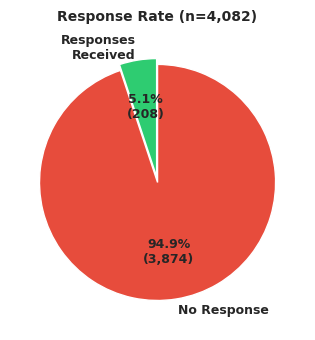

✅ Saved: survey_response_rate.png (single-column)


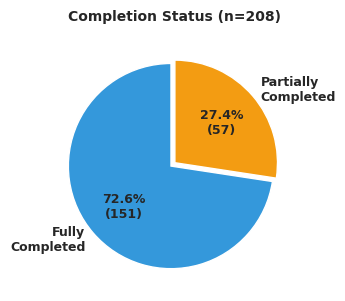

✅ Saved: survey_completion_status.png (single-column)

✅ Using 208 responses (with at least one pattern answer) for demographic analysis

--------------------------------------------------------------------------------
1. YEARS OF PROFESSIONAL SOFTWARE DEVELOPMENT EXPERIENCE
--------------------------------------------------------------------------------

Distribution:
  Answered: 208/208 (100.0%)
  Missing: 0/208 (0.0%)

Q01Q01. How many years of professional software development experience do you have?
1-3 years            29
4-7 years            50
8+ years            111
Less than 1 year     18

Percentages (of 208 responses):
  1-3 years: 29 (13.9%)
  4-7 years: 50 (24.0%)
  8+ years: 111 (53.4%)
  Less than 1 year: 18 (8.7%)

--------------------------------------------------------------------------------
2. PARTICIPANT LOCATION (COUNTRY)
--------------------------------------------------------------------------------

Total countries represented: 48
  Answered: 208/208 (100.0%)


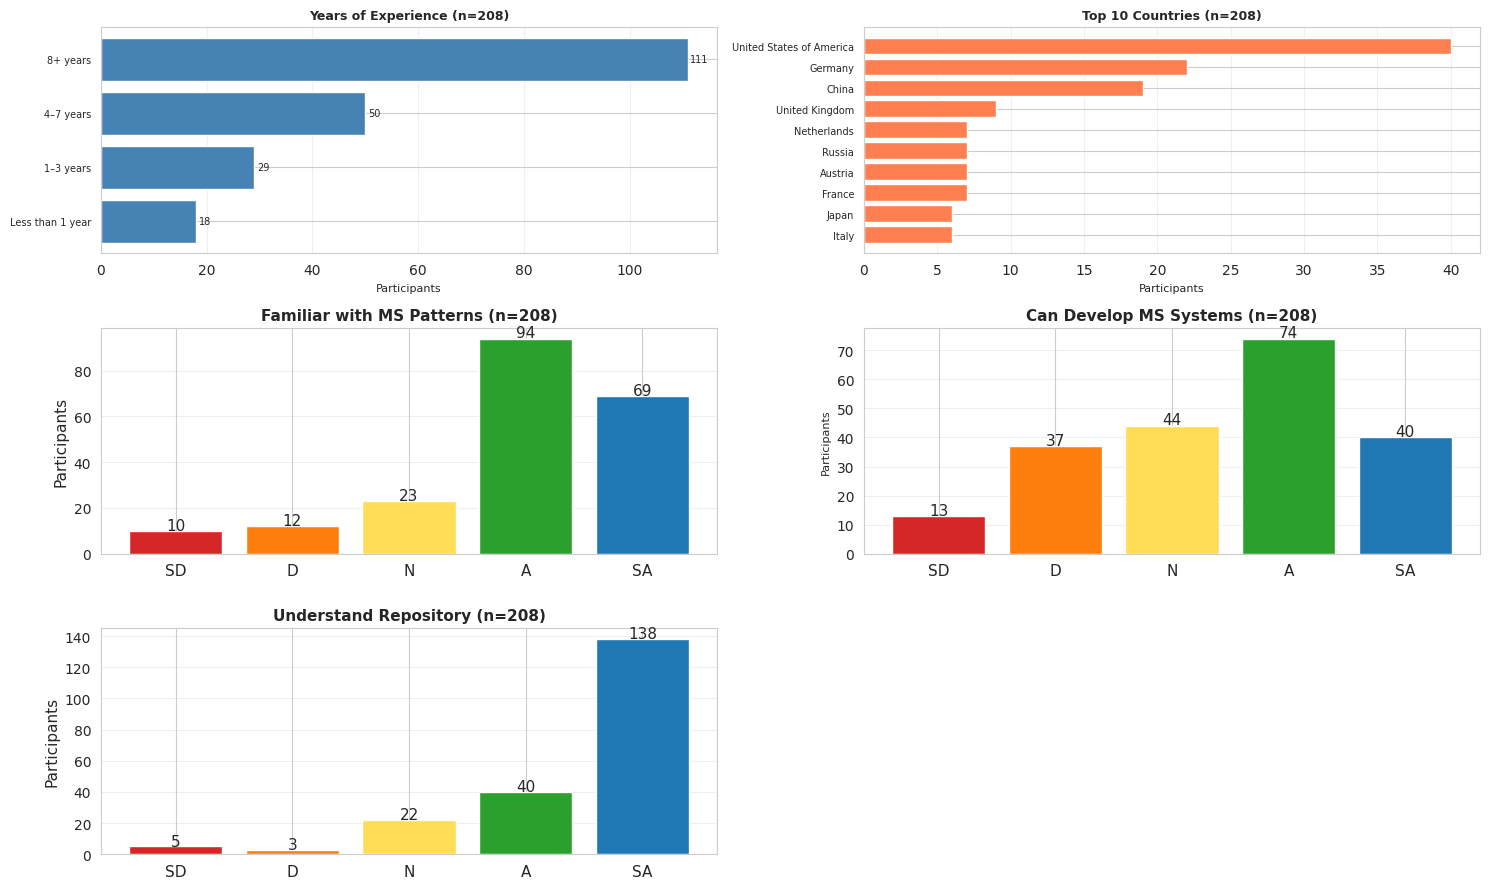

✅ Saved: survey_demographics_overview.png (double-column, 7 inches wide)


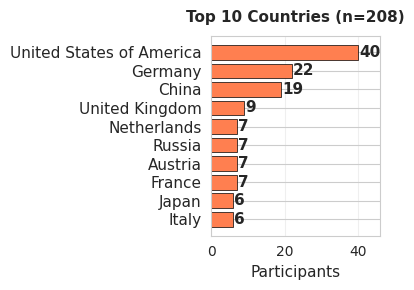

✅ Saved: survey_top10_countries.png (single-column)

Generating individual figures (IEEE format)...


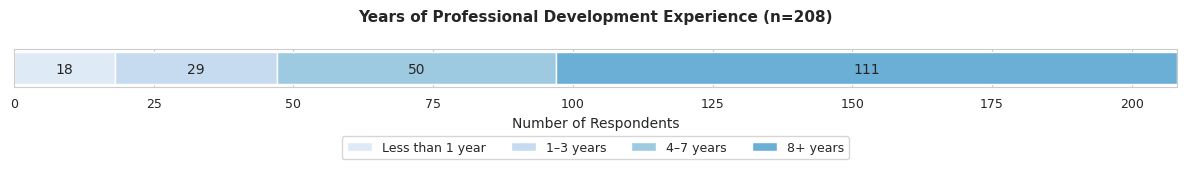

✅ Saved: survey_experience.png


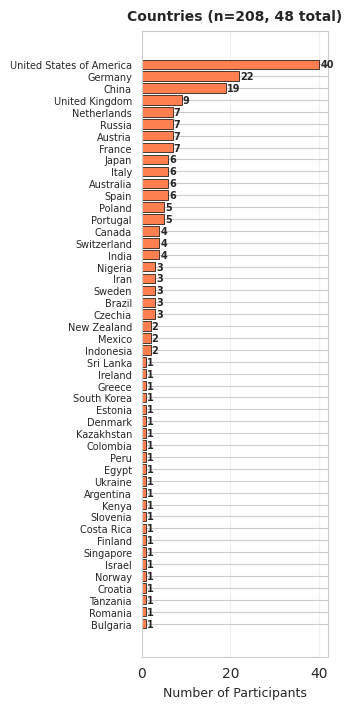

✅ Saved: survey_countries.png (single-column)


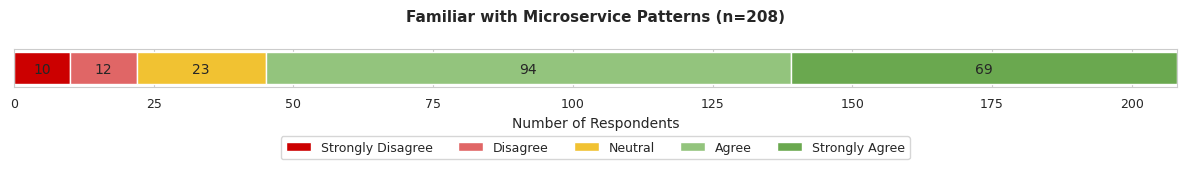

✅ Saved: survey_ms_familiar_likert.png


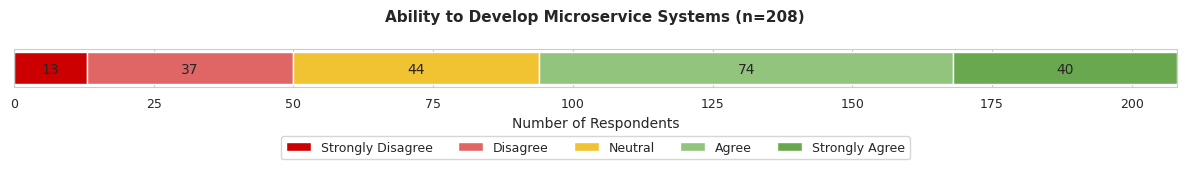

✅ Saved: survey_ms_develop_likert.png


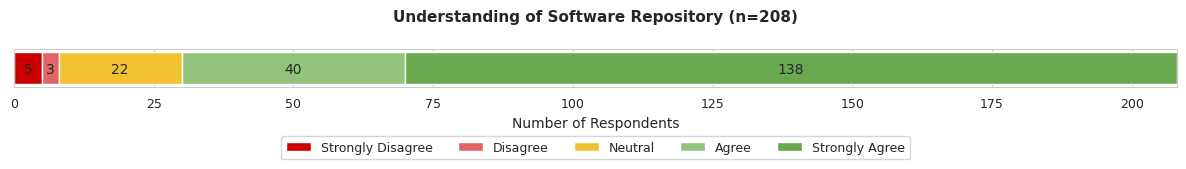

✅ Saved: survey_repo_understanding_likert.png

Generating combined Likert scale chart...


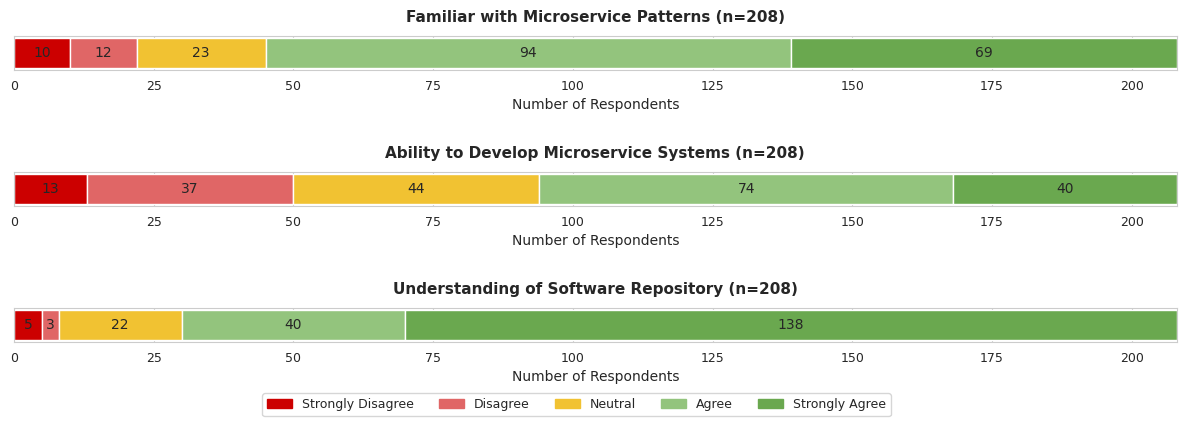

✅ Saved: survey_likert_combined.png

Saving summary statistics to CSV...

✅ Survey statistics saved to:
   Tables (CSV):
   - ./paper_tables/survey_completion_rates.csv
   - ./paper_tables/survey_experience.csv
   - ./paper_tables/survey_countries.csv
   - ./paper_tables/survey_ms_familiar.csv
   - ./paper_tables/survey_ms_develop.csv
   - ./paper_tables/survey_repo_understanding.csv

   Figures (PNG) - IEEE 2-COLUMN FORMAT:
   - ./paper_figures/survey_response_rate.png (single-column: 3.5")
   - ./paper_figures/survey_completion_status.png (single-column: 3.5")
   - ./paper_figures/survey_demographics_overview.png (double-column: 7")
   - ./paper_figures/survey_experience.png (single-column: 3.5")
   - ./paper_figures/survey_countries.png (single-column: 3.5")
   - ./paper_figures/survey_ms_familiar.png (single-column: 3.5")
   - ./paper_figures/survey_ms_develop.png (single-column: 3.5")
   - ./paper_figures/survey_repo_understanding.png (single-column: 3.5")

SURVEY ANALYSIS COMPLET

In [27]:
# ============================================================================
# CELL 10: Survey Demographics and Participant Statistics
# ============================================================================

print("\n" + "="*80)
print("SURVEY PARTICIPANT STATISTICS")
print("="*80)

# Load the survey data
survey_path = '../experiment_data/survey_responses_anonymized.csv'
survey_df = pd.read_csv(survey_path)

print(f"\n✅ Loaded survey data: {len(survey_df)} total entries")

# Define column names (they're quite long in the CSV)
col_experience = "Q01Q01. How many years of professional software development experience do you have?"
col_country = "G01Q05. What country are you based in?"
col_ms_familiar = "G01Q02[SQ002]. To what extent do you agree with the following sentences?  [I am familiar with the concept of microservice patterns]"
col_ms_develop = "G01Q02[SQ003]. To what extent do you agree with the following sentences?  [I know how to fully develop microservice-based systems (design, debug, optimize)]"
col_repo_understanding = "G01Q02[SQ004]. To what extent do you agree with the following sentences?  [I have a solid understanding of this software repository]"
col_submitdate = "submitdate. Date submitted"

# Get all pattern columns
pattern_cols = [col for col in survey_df.columns if 'G01Q04' in col and 'Are these patterns present' in col]
print(f"   Found {len(pattern_cols)} pattern question columns")

# ============================================================================
# SURVEY COMPLETION STATISTICS
# ============================================================================

print("\n" + "="*80)
print("SURVEY COMPLETION RATES")
print("="*80)

# Total invitations sent
total_invitations = contributor_stats['total_contributors']

# Responses received (at least one pattern answer)
has_pattern_answer = survey_df[pattern_cols].notna().any(axis=1)
partial_responses_df = survey_df[has_pattern_answer]

# Fully completed surveys (has submitdate)
has_submitdate = survey_df[col_submitdate].notna() & (survey_df[col_submitdate] != '')
fully_completed_df = survey_df[has_submitdate]

# Calculate statistics
num_partial = len(partial_responses_df)
num_fully_completed = len(fully_completed_df)
num_no_response = total_invitations - num_partial

print(f"\n📊 COMPLETION OVERVIEW:")
print(f"   Total invitations sent: {total_invitations}")
print(f"   Responses received: {num_partial} ({num_partial/total_invitations*100:.2f}%)")
print(f"   No response: {num_no_response} ({num_no_response/total_invitations*100:.2f}%)")

print(f"\n📊 RESPONSE BREAKDOWN:")
print(f"   Fully completed surveys: {num_fully_completed} ({num_fully_completed/total_invitations*100:.2f}% of invitations, {num_fully_completed/num_partial*100:.2f}% of responses)")
print(f"   Partially completed: {num_partial - num_fully_completed} ({(num_partial - num_fully_completed)/total_invitations*100:.2f}% of invitations, {(num_partial - num_fully_completed)/num_partial*100:.2f}% of responses)")

# Create completion summary dataframe
completion_summary = pd.DataFrame({
    'Status': ['No Response', 'Partial Response', 'Fully Completed', 'Total Responses', 'Total Invitations'],
    'Count': [
        num_no_response,
        num_partial - num_fully_completed,
        num_fully_completed,
        num_partial,
        total_invitations
    ],
    'Percentage of Invitations': [
        f"{num_no_response/total_invitations*100:.2f}%",
        f"{(num_partial - num_fully_completed)/total_invitations*100:.2f}%",
        f"{num_fully_completed/total_invitations*100:.2f}%",
        f"{num_partial/total_invitations*100:.2f}%",
        "100.00%"
    ],
    'Percentage of Responses': [
        "N/A",
        f"{(num_partial - num_fully_completed)/num_partial*100:.2f}%",
        f"{num_fully_completed/num_partial*100:.2f}%",
        "100.00%",
        "N/A"
    ]
})

print(f"\n📋 COMPLETION SUMMARY TABLE:")
print(completion_summary.to_string(index=False))

# Save to CSV
completion_summary.to_csv(Path(CONFIG['paper_tables_dir']) / 'survey_completion_rates.csv', index=False)
print(f"\n✅ Saved: {CONFIG['paper_tables_dir']}survey_completion_rates.csv")

# ============================================================================
# VISUALIZE COMPLETION RATES - SEPARATE FIGURES (IEEE 2-COLUMN FORMAT)
# ============================================================================

print("\n" + "-"*80)
print("GENERATING COMPLETION RATE VISUALIZATIONS (IEEE 2-COLUMN FORMAT)")
print("-"*80)

# Helper function to create stacked bar chart (matching exact style)
# Helper function to create stacked bar chart (flexible for any number of categories)
def create_likert_chart(data, labels, title, filename, n_respondents, colors=None):
    """
    Create a horizontal stacked bar chart.
    Works for Likert scale (5 categories) or any other number of categories.
    """
    import numpy as np
    
    # Default colors if not provided (5-category Likert scale)
    if colors is None:
        colors = ['#cc0000', '#e06666', '#f1c232', '#93c47d', '#6aa84f']
    
    # Adjust these values to change appearance
    bar_height = 2
    text_y = -0.3
    ylim_range = 1.2
    
    x = [""]
    
    plt.figure(figsize=(15, 0.5))
    plt.ylim(-ylim_range, ylim_range)
    
    # Plot stacked bars dynamically
    cumsum = 0
    for i, (value, color) in enumerate(zip(data, colors)):
        y = np.array(value)
        plt.barh(x, y, left=cumsum, color=color, height=bar_height)
        plt.text(cumsum + y/2, text_y, np.array2string(y, precision=2, separator=',', suppress_small=True), ha='center')
        cumsum += y
    
    plt.xlim(0, cumsum)
    plt.xlabel('Number of Respondents', fontsize=10)
    plt.title(f'{title} (n={n_respondents})', pad=20, fontweight='bold', fontsize=11)
    plt.tick_params(axis='both', labelsize=9)
    plt.legend(labels=labels, bbox_to_anchor=(0.5, -1.1), loc='upper center', ncol=len(labels), fontsize=9)
    
    plt.savefig(Path(CONFIG['paper_figures_dir']) / filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")

# Figure 1: Response Rate (Response vs No Response) - Single column size
fig1, ax1 = plt.subplots(figsize=(3.5, 3.5))

response_labels = ['Responses\nReceived', 'No Response']
response_sizes = [num_partial, num_no_response]
response_colors = ['#2ecc71', '#e74c3c']
response_explode = (0.05, 0)

ax1.pie(response_sizes, explode=response_explode, labels=response_labels, colors=response_colors,
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*total_invitations):,})',
        startangle=90, textprops={'fontsize': 9, 'fontweight': 'bold'})
ax1.set_title(f'Response Rate (n={total_invitations:,})', 
              fontsize=10, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig(Path(CONFIG['paper_figures_dir']) / 'survey_response_rate.png', 
           dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: survey_response_rate.png (single-column)")

# Figure 2: Completion Status (Fully Complete vs Partial, of responses) - Single column size
fig2, ax2 = plt.subplots(figsize=(3.5, 3.5))

completion_labels = ['Fully\nCompleted', 'Partially\nCompleted']
completion_sizes = [num_fully_completed, num_partial - num_fully_completed]
completion_colors = ['#3498db', '#f39c12']
completion_explode = (0.05, 0)

ax2.pie(completion_sizes, explode=completion_explode, labels=completion_labels, colors=completion_colors,
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*num_partial):,})',
        startangle=90, textprops={'fontsize': 9, 'fontweight': 'bold'})
ax2.set_title(f'Completion Status (n={num_partial})', 
              fontsize=10, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig(Path(CONFIG['paper_figures_dir']) / 'survey_completion_status.png', 
           dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: survey_completion_status.png (single-column)")

# Use the partial_responses_df for all subsequent analyses
complete_df = partial_responses_df

print(f"\n✅ Using {len(complete_df)} responses (with at least one pattern answer) for demographic analysis")

# ============================================================================
# 1. YEARS OF EXPERIENCE
# ============================================================================

print("\n" + "-"*80)
print("1. YEARS OF PROFESSIONAL SOFTWARE DEVELOPMENT EXPERIENCE")
print("-"*80)

experience_counts = complete_df[col_experience].value_counts().sort_index()
experience_answered = experience_counts.sum()
experience_missing = len(complete_df) - experience_answered

print(f"\nDistribution:")
print(f"  Answered: {experience_answered}/{len(complete_df)} ({experience_answered/len(complete_df)*100:.1f}%)")
print(f"  Missing: {experience_missing}/{len(complete_df)} ({experience_missing/len(complete_df)*100:.1f}%)")
print()
print(experience_counts.to_string())

# Calculate percentages
if experience_answered > 0:
    print(f"\nPercentages (of {experience_answered} responses):")
    for exp, count in experience_counts.items():
        print(f"  {exp}: {count} ({count/experience_answered*100:.1f}%)")

# ============================================================================
# 2. COUNTRY/LOCATION
# ============================================================================

print("\n" + "-"*80)
print("2. PARTICIPANT LOCATION (COUNTRY)")
print("-"*80)

country_counts = complete_df[col_country].value_counts()
country_answered = country_counts.sum()
country_missing = len(complete_df) - country_answered

print(f"\nTotal countries represented: {len(country_counts)}")
print(f"  Answered: {country_answered}/{len(complete_df)} ({country_answered/len(complete_df)*100:.1f}%)")
print(f"  Missing: {country_missing}/{len(complete_df)} ({country_missing/len(complete_df)*100:.1f}%)")
print(f"\nTop 10 countries:")
print(country_counts.head(10).to_string())

# ============================================================================
# 3. FAMILIARITY WITH MICROSERVICE PATTERNS (SQ002)
# ============================================================================

print("\n" + "-"*80)
print("3. FAMILIARITY WITH MICROSERVICE PATTERNS (SQ002)")
print("-"*80)

# Define order for Likert scale
likert_order = ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']

ms_familiar_counts = complete_df[col_ms_familiar].value_counts()
ms_familiar_answered = ms_familiar_counts.sum()
ms_familiar_missing = len(complete_df) - ms_familiar_answered

print(f"\nQuestion: 'I am familiar with the concept of microservice patterns'")
print(f"\nDistribution:")
print(f"  Answered: {ms_familiar_answered}/{len(complete_df)} ({ms_familiar_answered/len(complete_df)*100:.1f}%)")
print(f"  Missing: {ms_familiar_missing}/{len(complete_df)} ({ms_familiar_missing/len(complete_df)*100:.1f}%)")
print()

# Sort by Likert scale order
for level in likert_order:
    if level in ms_familiar_counts.index:
        count = ms_familiar_counts[level]
        print(f"  {level}: {count} ({count/ms_familiar_answered*100:.1f}%)")

# ============================================================================
# 4. ABILITY TO DEVELOP MICROSERVICE SYSTEMS (SQ003)
# ============================================================================

print("\n" + "-"*80)
print("4. ABILITY TO DEVELOP MICROSERVICE SYSTEMS (SQ003)")
print("-"*80)

ms_develop_counts = complete_df[col_ms_develop].value_counts()
ms_develop_answered = ms_develop_counts.sum()
ms_develop_missing = len(complete_df) - ms_develop_answered

print(f"\nQuestion: 'I know how to fully develop microservice-based systems (design, debug, optimize)'")
print(f"\nDistribution:")
print(f"  Answered: {ms_develop_answered}/{len(complete_df)} ({ms_develop_answered/len(complete_df)*100:.1f}%)")
print(f"  Missing: {ms_develop_missing}/{len(complete_df)} ({ms_develop_missing/len(complete_df)*100:.1f}%)")
print()

# Sort by Likert scale order
for level in likert_order:
    if level in ms_develop_counts.index:
        count = ms_develop_counts[level]
        print(f"  {level}: {count} ({count/ms_develop_answered*100:.1f}%)")

# ============================================================================
# 5. UNDERSTANDING OF SOFTWARE REPOSITORY (SQ004)
# ============================================================================

print("\n" + "-"*80)
print("5. UNDERSTANDING OF SOFTWARE REPOSITORY (SQ004)")
print("-"*80)

repo_understanding_counts = complete_df[col_repo_understanding].value_counts()
repo_understanding_answered = repo_understanding_counts.sum()
repo_understanding_missing = len(complete_df) - repo_understanding_answered

print(f"\nQuestion: 'I have a solid understanding of this software repository'")
print(f"\nDistribution:")
print(f"  Answered: {repo_understanding_answered}/{len(complete_df)} ({repo_understanding_answered/len(complete_df)*100:.1f}%)")
print(f"  Missing: {repo_understanding_missing}/{len(complete_df)} ({repo_understanding_missing/len(complete_df)*100:.1f}%)")
print()

# Sort by Likert scale order
for level in likert_order:
    if level in repo_understanding_counts.index:
        count = repo_understanding_counts[level]
        print(f"  {level}: {count} ({count/repo_understanding_answered*100:.1f}%)")

# ============================================================================
# VISUALIZATIONS - OVERVIEW (IEEE 2-COLUMN FORMAT - DOUBLE COLUMN WIDTH)
# ============================================================================

print("\n" + "-"*80)
print("GENERATING VISUALIZATIONS (IEEE 2-COLUMN FORMAT)")
print("-"*80)

# Overview figure (3x2 grid) - double column width for IEEE
fig, axes = plt.subplots(3, 2, figsize=(15, 9))

# 1. Years of Experience
ax1 = axes[0, 0]
# Define correct order and labels with en dashes
exp_order = ['Less than 1 year', '1-3 years', '4-7 years', '8+ years']
exp_labels_display = ['Less than 1 year', '1–3 years', '4–7 years', '8+ years']
exp_data = experience_counts.reindex(exp_order)
ax1.barh(range(len(exp_data)), exp_data.values, color='steelblue')
ax1.set_yticks(range(len(exp_data)))
ax1.set_yticklabels(exp_labels_display, fontsize=7)
ax1.set_xlabel('Participants', fontsize=8)
ax1.set_title(f'Years of Experience (n={experience_answered})', 
              fontsize=9, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(exp_data.values):
    ax1.text(v + 0.5, i, str(v), va='center', fontsize=7)

# 2. Top 10 Countries
ax2 = axes[0, 1]
top_countries = country_counts.head(10)
ax2.barh(range(len(top_countries)), top_countries.values, color='coral')
ax2.set_yticks(range(len(top_countries)))
ax2.set_yticklabels(top_countries.index, fontsize=7)
ax2.set_xlabel('Participants', fontsize=8)
ax2.set_title(f'Top 10 Countries (n={country_answered})', 
              fontsize=9, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

# 3. Familiar with Microservice Patterns (SQ002)
ax3 = axes[1, 0]
ms_familiar_data = [ms_familiar_counts.get(level, 0) for level in likert_order]
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c', '#1f77b4']
ax3.bar(range(len(likert_order)), ms_familiar_data, color=colors)
ax3.set_xticks(range(len(likert_order)))
ax3.set_xticklabels(['SD', 'D', 'N', 'A', 'SA'], fontsize=11)
ax3.set_ylabel('Participants', fontsize=11)
ax3.set_title(f'Familiar with MS Patterns (n={ms_familiar_answered})', 
              fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(ms_familiar_data):
    if v > 0:
        ax3.text(i, v + 0.5, str(v), ha='center', fontsize=11)

# 4. Ability to Develop Microservice Systems (SQ003)
ax4 = axes[1, 1]
ms_develop_data = [ms_develop_counts.get(level, 0) for level in likert_order]
ax4.bar(range(len(likert_order)), ms_develop_data, color=colors)
ax4.set_xticks(range(len(likert_order)))
ax4.set_xticklabels(['SD', 'D', 'N', 'A', 'SA'], fontsize=11)
ax4.set_ylabel('Participants', fontsize=8)
ax4.set_title(f'Can Develop MS Systems (n={ms_develop_answered})', 
              fontsize=11, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for i, v in enumerate(ms_develop_data):
    if v > 0:
        ax4.text(i, v + 0.5, str(v), ha='center', fontsize=11)

# 5. Understanding of Repository (SQ004)
ax5 = axes[2, 0]
repo_understanding_data = [repo_understanding_counts.get(level, 0) for level in likert_order]
ax5.bar(range(len(likert_order)), repo_understanding_data, color=colors)
ax5.set_xticks(range(len(likert_order)))
ax5.set_xticklabels(['SD', 'D', 'N', 'A', 'SA'], fontsize=11)
ax5.set_ylabel('Participants', fontsize=11)
ax5.set_title(f'Understand Repository (n={repo_understanding_answered})', 
              fontsize=11, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)
for i, v in enumerate(repo_understanding_data):
    if v > 0:
        ax5.text(i, v + 0.5, str(v), ha='center', fontsize=11)

# 6. Hide the last subplot (bottom right)
axes[2, 1].axis('off')

plt.tight_layout()
plt.savefig(Path(CONFIG['paper_figures_dir']) / 'survey_demographics_overview.png', 
           dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: survey_demographics_overview.png (double-column, 7 inches wide)")

# ============================================================================
# EXTRACT: Top 10 Countries as Separate Image
# ============================================================================

# Create a new standalone figure for top 10 countries
fig_top10, ax_top10 = plt.subplots(figsize=(4, 3))
top_countries = country_counts.head(10)
ax_top10.barh(range(len(top_countries)), top_countries.values, color='coral', edgecolor='black', linewidth=0.5)
ax_top10.set_yticks(range(len(top_countries)))
ax_top10.set_yticklabels(top_countries.index, fontsize=11)
ax_top10.set_xlabel('Participants', fontsize=11)
ax_top10.set_title(f'Top 10 Countries (n={country_answered})', 
                   fontsize=11, fontweight='bold', pad=10)
ax_top10.grid(axis='x', alpha=0.3)
ax_top10.invert_yaxis()

# Add value labels
for i, v in enumerate(top_countries.values):
    ax_top10.text(v + 0.3, i, str(v), va='center', fontsize=11, fontweight='bold')

# Set x-axis limit to ensure labels fit inside graph
ax_top10.set_xlim(0, max(top_countries.values) * 1.15)

plt.tight_layout()
plt.savefig(Path(CONFIG['paper_figures_dir']) / 'survey_top10_countries.png', 
           dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: survey_top10_countries.png (single-column)")


# ============================================================================
# INDIVIDUAL FIGURES (IEEE 2-COLUMN FORMAT)
# ============================================================================

print("\nGenerating individual figures (IEEE format)...")

# Figure 1: Years of Experience - Using same function as Likert charts
# Define correct order and labels with en dashes
exp_order = ['Less than 1 year', '1-3 years', '4-7 years', '8+ years']
exp_labels_display = ['Less than 1 year', '1–3 years', '4–7 years', '8+ years']
exp_data = experience_counts.reindex(exp_order)
exp_values = list(exp_data.values)
exp_labels = exp_labels_display

# Colors for experience levels (gradient)
exp_colors = ['#deebf7', '#c6dbef', '#9ecae1', '#6baed6', '#4292c6', '#2171b5', '#084594'][:len(exp_values)]

create_likert_chart(
    data=exp_values,
    labels=exp_labels,
    title='Years of Professional Development Experience',
    filename='survey_experience.png',
    n_respondents=experience_answered,
    colors=exp_colors
)

# Figure 2: Countries - Single column, compact
fig2, ax = plt.subplots(figsize=(3.5, max(3, len(country_counts) * 0.15)))
ax.barh(range(len(country_counts)), country_counts.values, color='coral', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(country_counts)))
ax.set_yticklabels(country_counts.index, fontsize=7)
ax.set_xlabel('Number of Participants', fontsize=9)
ax.set_title(f'Countries (n={country_answered}, {len(country_counts)} total)', 
            fontsize=10, fontweight='bold', pad=8)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
for i, v in enumerate(country_counts.values):
    ax.text(v + 0.2, i, str(v), va='center', fontsize=7, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(CONFIG['paper_figures_dir']) / 'survey_countries.png', 
           dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: survey_countries.png (single-column)")

# ============================================================================
# COMPACT LIKERT-SCALE FIGURES (DIVERGING STACKED BAR CHARTS)
# ============================================================================

# Figure 3: Familiar with Microservice Patterns (SQ002)
ms_familiar_data = [ms_familiar_counts.get(level, 0) for level in likert_order]
create_likert_chart(
    data=ms_familiar_data,
    labels=['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree'],
    title='Familiar with Microservice Patterns',
    filename='survey_ms_familiar_likert.png',
    n_respondents=ms_familiar_answered
)

# Figure 4: Ability to Develop Microservice Systems (SQ003)
ms_develop_data = [ms_develop_counts.get(level, 0) for level in likert_order]
create_likert_chart(
    data=ms_develop_data,
    labels=['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree'],
    title='Ability to Develop Microservice Systems',
    filename='survey_ms_develop_likert.png',
    n_respondents=ms_develop_answered
)

# Figure 5: Understanding of Repository (SQ004)
repo_understanding_data = [repo_understanding_counts.get(level, 0) for level in likert_order]
create_likert_chart(
    data=repo_understanding_data,
    labels=['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree'],
    title='Understanding of Software Repository',
    filename='survey_repo_understanding_likert.png',
    n_respondents=repo_understanding_answered
)

# ============================================================================
# COMBINED LIKERT CHART (Figures 3, 4, 5 combined with shared legend)
# ============================================================================

print("\nGenerating combined Likert scale chart...")

# Prepare data for all 3 questions
likert_questions = [
    {
        'data': ms_familiar_data,
        'title': 'Familiar with Microservice Patterns',
        'n': ms_familiar_answered
    },
    {
        'data': ms_develop_data,
        'title': 'Ability to Develop Microservice Systems',
        'n': ms_develop_answered
    },
    {
        'data': repo_understanding_data,
        'title': 'Understanding of Software Repository',
        'n': repo_understanding_answered
    }
]

likert_labels = ['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree']
likert_colors = ['#cc0000', '#e06666', '#f1c232', '#93c47d', '#6aa84f']

# Create figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 4.5))
fig.subplots_adjust(hspace=3, bottom=0.2)

# Add separation line at the very top of figure (matching plot width)
line = plt.Line2D([0, 1], [2.15, 2.15], transform=axes[0].transAxes, color='black', linewidth=1.5, clip_on=False)
axes[0].add_line(line)

for idx, (ax, question) in enumerate(zip(axes, likert_questions)):
    data = question['data']
    title = question['title']
    n = question['n']
    
    # Plot stacked bars
    x = [""]
    bar_height = 1.4
    text_y = -0.2
    cumsum = 0
    
    for i, (value, color) in enumerate(zip(data, likert_colors)):
        y = np.array(value)
        ax.barh(x, y, left=cumsum, color=color, height=bar_height)
        ax.text(cumsum + y/2, text_y, np.array2string(y, precision=2, separator=',', suppress_small=True), ha='center')
        cumsum += y
    
    # Set limits and labels
    ax.set_ylim(-0.8, 0.8)
    ax.set_xlim(0, cumsum)
    ax.set_yticks([])
    ax.set_xlabel('Number of Respondents', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)
    
    # Bold titles
    ax.set_title(f'{title} (n={n})', pad=10, fontweight='bold', fontsize=11)

# Create a single shared legend at the bottom
handles = [plt.Rectangle((0,0),1,1, color=color) for color in likert_colors]
fig.legend(handles, likert_labels, bbox_to_anchor=(0.5, 0.1), loc='upper center', ncol=5, fontsize=9)

plt.savefig(Path(CONFIG['paper_figures_dir']) / 'survey_likert_combined.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: survey_likert_combined.png")


# ============================================================================
# SAVE STATISTICS TO CSV
# ============================================================================

print("\nSaving summary statistics to CSV...")

# Create summary dataframes
experience_summary = pd.DataFrame({
    'Experience Level': list(experience_counts.index) + ['Missing'],
    'Count': list(experience_counts.values) + [experience_missing],
    'Percentage': [f"{v/len(complete_df)*100:.1f}%" for v in experience_counts.values] + [f"{experience_missing/len(complete_df)*100:.1f}%"]
})

country_summary = pd.DataFrame({
    'Country': list(country_counts.index) + ['Missing'],
    'Count': list(country_counts.values) + [country_missing],
    'Percentage': [f"{v/len(complete_df)*100:.1f}%" for v in country_counts.values] + [f"{country_missing/len(complete_df)*100:.1f}%"]
})

ms_familiar_summary = pd.DataFrame({
    'Knowledge Level': likert_order + ['Missing'],
    'Count': [ms_familiar_counts.get(level, 0) for level in likert_order] + [ms_familiar_missing],
    'Percentage': [f"{ms_familiar_counts.get(level, 0)/len(complete_df)*100:.1f}%" for level in likert_order] + [f"{ms_familiar_missing/len(complete_df)*100:.1f}%"]
})

ms_develop_summary = pd.DataFrame({
    'Knowledge Level': likert_order + ['Missing'],
    'Count': [ms_develop_counts.get(level, 0) for level in likert_order] + [ms_develop_missing],
    'Percentage': [f"{ms_develop_counts.get(level, 0)/len(complete_df)*100:.1f}%" for level in likert_order] + [f"{ms_develop_missing/len(complete_df)*100:.1f}%"]
})

repo_understanding_summary = pd.DataFrame({
    'Knowledge Level': likert_order + ['Missing'],
    'Count': [repo_understanding_counts.get(level, 0) for level in likert_order] + [repo_understanding_missing],
    'Percentage': [f"{repo_understanding_counts.get(level, 0)/len(complete_df)*100:.1f}%" for level in likert_order] + [f"{repo_understanding_missing/len(complete_df)*100:.1f}%"]
})

# Save to CSV files
experience_summary.to_csv(Path(CONFIG['paper_tables_dir']) / 'survey_experience.csv', index=False)
country_summary.to_csv(Path(CONFIG['paper_tables_dir']) / 'survey_countries.csv', index=False)
ms_familiar_summary.to_csv(Path(CONFIG['paper_tables_dir']) / 'survey_ms_familiar.csv', index=False)
ms_develop_summary.to_csv(Path(CONFIG['paper_tables_dir']) / 'survey_ms_develop.csv', index=False)
repo_understanding_summary.to_csv(Path(CONFIG['paper_tables_dir']) / 'survey_repo_understanding.csv', index=False)

print("\n✅ Survey statistics saved to:")
print(f"   Tables (CSV):")
print(f"   - {CONFIG['paper_tables_dir']}survey_completion_rates.csv")
print(f"   - {CONFIG['paper_tables_dir']}survey_experience.csv")
print(f"   - {CONFIG['paper_tables_dir']}survey_countries.csv")
print(f"   - {CONFIG['paper_tables_dir']}survey_ms_familiar.csv")
print(f"   - {CONFIG['paper_tables_dir']}survey_ms_develop.csv")
print(f"   - {CONFIG['paper_tables_dir']}survey_repo_understanding.csv")
print(f"\n   Figures (PNG) - IEEE 2-COLUMN FORMAT:")
print(f"   - {CONFIG['paper_figures_dir']}survey_response_rate.png (single-column: 3.5\")")
print(f"   - {CONFIG['paper_figures_dir']}survey_completion_status.png (single-column: 3.5\")")
print(f"   - {CONFIG['paper_figures_dir']}survey_demographics_overview.png (double-column: 7\")")
print(f"   - {CONFIG['paper_figures_dir']}survey_experience.png (single-column: 3.5\")")
print(f"   - {CONFIG['paper_figures_dir']}survey_countries.png (single-column: 3.5\")")
print(f"   - {CONFIG['paper_figures_dir']}survey_ms_familiar.png (single-column: 3.5\")")
print(f"   - {CONFIG['paper_figures_dir']}survey_ms_develop.png (single-column: 3.5\")")
print(f"   - {CONFIG['paper_figures_dir']}survey_repo_understanding.png (single-column: 3.5\")")

print("\n" + "="*80)
print("SURVEY ANALYSIS COMPLETE")
print("="*80)

In [28]:
# ============================================================================
# PATTERN CONFUSION ANALYSIS
# For each pattern, when it's misdetected (False Negative), 
# what are the top 3 patterns that were incorrectly detected instead (False Positives)?
# ============================================================================

from collections import defaultdict, Counter

# Dictionary to store confusion data: {missed_pattern: Counter({incorrectly_detected_pattern: count})}
pattern_confusion = defaultdict(Counter)

# Iterate through all reports and ground truth
for report in all_reports:
    repo_name = report['summary']['repository_name']
    
    # Skip if repo not in ground truth
    if repo_name not in ground_truth:
        continue
    
    gt_patterns = ground_truth[repo_name]['patterns']
    detected_patterns = report['patterns']
    
    # For each pattern, check if it was missed (False Negative)
    for pattern_name in patterns:
        # Check if this pattern should have been detected but wasn't
        if gt_patterns.get(pattern_name, False) and not detected_patterns.get(pattern_name, False):
            # This is a False Negative for this pattern
            # Now find what patterns were incorrectly detected (False Positives) in this repo
            for other_pattern in patterns:
                if other_pattern != pattern_name:
                    # Check if other_pattern was detected but shouldn't have been
                    if detected_patterns.get(other_pattern, False) and not gt_patterns.get(other_pattern, False):
                        # This is a False Positive - count it as confusion
                        pattern_confusion[pattern_name][other_pattern] += 1

# Display results
print("=" * 100)
print("PATTERN CONFUSION ANALYSIS")
print("=" * 100)
print("\nWhen each pattern is MISSED (False Negative), these are the patterns that were")
print("INCORRECTLY DETECTED (False Positive) instead:\n")

for pattern_name in sorted(pattern_confusion.keys()):
    print(f"\n{'='*100}")
    print(f"Pattern: '{pattern_name}'")
    print(f"{'='*100}")
    
    # Get top 3 confused patterns
    top_3 = pattern_confusion[pattern_name].most_common(3)
    
    if top_3:
        print(f"Total times missed: {sum(pattern_confusion[pattern_name].values())} repositories")
        print(f"\nTop 3 patterns incorrectly detected instead:")
        for i, (confused_pattern, count) in enumerate(top_3, 1):
            percentage = (count / sum(pattern_confusion[pattern_name].values())) * 100
            print(f"  {i}. '{confused_pattern}': {count} times ({percentage:.1f}%)")
    else:
        print("  No confusion patterns found (this pattern was never missed)")

# Create a summary DataFrame for easier analysis
confusion_summary = []
for pattern, counter in pattern_confusion.items():
    top_3 = counter.most_common(3)
    total_misses = sum(counter.values())
    
    row = {
        'Pattern': pattern,
        'Times_Missed': total_misses,
    }
    
    for i in range(3):
        if i < len(top_3):
            row[f'Top_{i+1}_Confused_Pattern'] = top_3[i][0]
            row[f'Top_{i+1}_Count'] = top_3[i][1]
            row[f'Top_{i+1}_Percentage'] = f"{(top_3[i][1] / total_misses * 100):.1f}%"
        else:
            row[f'Top_{i+1}_Confused_Pattern'] = None
            row[f'Top_{i+1}_Count'] = 0
            row[f'Top_{i+1}_Percentage'] = "0.0%"
    
    confusion_summary.append(row)

confusion_df = pd.DataFrame(confusion_summary).sort_values('Times_Missed', ascending=False)

print("\n" + "="*100)
print("SUMMARY TABLE")
print("="*100)
print(confusion_df.to_string(index=False))

# Optional: Visualize the confusion as a heatmap
print("\n" + "="*100)
print("CONFUSION MATRIX (showing how often each pattern pair is confused)")
print("="*100)

# Create a matrix showing confusion between patterns
confusion_matrix = pd.DataFrame(0, index=patterns, columns=patterns)
for missed_pattern, confused_counter in pattern_confusion.items():
    for confused_pattern, count in confused_counter.items():
        confusion_matrix.loc[missed_pattern, confused_pattern] = count

print("\nRows: Patterns that were MISSED (should be detected but weren't)")
print("Columns: Patterns that were INCORRECTLY DETECTED (detected but shouldn't be)")
print("Values: Number of repositories where this confusion occurred\n")
print(confusion_matrix)

PATTERN CONFUSION ANALYSIS

When each pattern is MISSED (False Negative), these are the patterns that were
INCORRECTLY DETECTED (False Positive) instead:


Pattern: '3rd Party Registration'
Total times missed: 7 repositories

Top 3 patterns incorrectly detected instead:
  1. 'Service deployment platform': 2 times (28.6%)
  2. 'Server-side service discovery': 2 times (28.6%)
  3. 'Service instance per container': 2 times (28.6%)

Pattern: 'Multiple service instances per host'
Total times missed: 7 repositories

Top 3 patterns incorrectly detected instead:
  1. 'Service deployment platform': 3 times (42.9%)
  2. 'Server-side service discovery': 2 times (28.6%)
  3. 'Service instance per container': 1 times (14.3%)

Pattern: 'Server-side service discovery'
Total times missed: 2 repositories

Top 3 patterns incorrectly detected instead:
  1. 'Service deployment platform': 1 times (50.0%)
  2. 'Single Service Instance per Host': 1 times (50.0%)

Pattern: 'Service deployment platform'
Total 

In [29]:
# ============================================================================
# FILE DOMINANCE INDEX ANALYSIS
# ============================================================================
# 
# This analysis calculates the File Dominance Index (FDI) for each file type
# per pattern. The FDI measures how much more frequently a specific file is 
# analyzed compared to the average file when detecting a pattern.
#
# Mathematical Definition:
# ------------------------
# For a pattern P with N unique filenames and total occurrences T:
#
#   FDI_i = c_i / μ
#
# Where:
#   - FDI_i = File Dominance Index for file i
#   - c_i = number of occurrences of file i
#   - μ = T/N = average count per unique file
#   - T = Σ(c_j) for all j = total file occurrences
#   - N = number of unique filenames
#
# Equivalently:
#   FDI_i = (c_i × N) / T
#
# Interpretation:
#   - FDI = 1: File is analyzed exactly at the average rate
#   - FDI > 1: File is analyzed MORE than average (dominant)
#   - FDI < 1: File is analyzed LESS than average
#   - FDI = 50: File is analyzed 50× more than average
# ============================================================================

print("\n" + "="*80)
print("FILE DOMINANCE INDEX (FDI) ANALYSIS")
print("="*80)

print("\nFormula: FDI_i = c_i / μ, where μ = Total_Occurrences / Unique_Files")
print("Interpretation: FDI > 1 means file is analyzed more than average\n")

# Calculate FDI for each pattern
fdi_results = []

for pattern in sorted(pattern_filenames_detected.keys()):
    counter = pattern_filenames_detected[pattern]
    if not counter:
        continue
        
    total_occurrences = sum(counter.values())
    unique_files = len(counter)
    avg_count = total_occurrences / unique_files  # μ
    
    # Calculate FDI for top 10 files
    top_10 = counter.most_common(10)
    
    print(f"\n{pattern}")
    print(f"  Total occurrences (T): {total_occurrences}")
    print(f"  Unique files (N): {unique_files}")
    print(f"  Average count (μ = T/N): {avg_count:.2f}")
    print(f"\n  {'Rank':<6} {'Filename':<35} {'Count (c_i)':<12} {'FDI':<10}")
    print(f"  {'-'*70}")
    
    for rank, (filename, count) in enumerate(top_10, 1):
        fdi = count / avg_count
        print(f"  {rank:<6} {filename[:33]:<35} {count:<12} {fdi:<10.2f}")
        
        fdi_results.append({
            'Pattern': pattern,
            'Rank': rank,
            'Filename': filename,
            'Count': count,
            'FDI': round(fdi, 2)
        })

# Create summary DataFrame
fdi_df = pd.DataFrame(fdi_results)

# Export to CSV for paper
fdi_output_path = Path(CONFIG['paper_tables_dir']) / 'file_dominance_index.csv'
fdi_df.to_csv(fdi_output_path, index=False)
print(f"\n✅ Saved: {fdi_output_path}")

# Create summary table showing only top 3 per pattern
print("\n" + "="*80)
print("SUMMARY: Top 3 Dominant Files per Pattern")
print("="*80)
top3_df = fdi_df[fdi_df['Rank'] <= 3].copy()
print(top3_df.to_string(index=False))

# Statistical summary
print("\n" + "="*80)
print("FDI STATISTICS")
print("="*80)

fdi_stats = []
for pattern in sorted(pattern_filenames_detected.keys()):
    counter = pattern_filenames_detected[pattern]
    if not counter:
        continue
    
    total_occurrences = sum(counter.values())
    unique_files = len(counter)
    avg_count = total_occurrences / unique_files
    
    top1_count = counter.most_common(1)[0][1]
    max_fdi = top1_count / avg_count
    
    fdi_stats.append({
        'Pattern': pattern,
        'Max_FDI': round(max_fdi, 2),
        'Top_File': counter.most_common(1)[0][0]
    })

fdi_stats_df = pd.DataFrame(fdi_stats).sort_values('Max_FDI', ascending=False)
print("\nPatterns ranked by maximum File Dominance Index:")
print(fdi_stats_df.to_string(index=False))

print("\nInterpretation:")
print("- High FDI (>20): Strong concentration - specific file types dominate pattern detection")
print("- Medium FDI (5-20): Moderate concentration - some preferred files but diverse evidence")
print("- Low FDI (<5): High dispersion - pattern evidence spread across many file types")


FILE DOMINANCE INDEX (FDI) ANALYSIS

Formula: FDI_i = c_i / μ, where μ = Total_Occurrences / Unique_Files
Interpretation: FDI > 1 means file is analyzed more than average


3rd Party Registration
  Total occurrences (T): 56
  Unique files (N): 54
  Average count (μ = T/N): 1.04

  Rank   Filename                            Count (c_i)  FDI       
  ----------------------------------------------------------------------
  1      docker-compose.yaml                 2            1.93      
  2      external_registry.cpp               2            1.93      
  3      servicediscovery.md                 1            0.96      
  4      DnsRegistrationService.java         1            0.96      
  5      xorcery.yaml                        1            0.96      
  6      ServerResourceDocument.java         1            0.96      
  7      ServiceAttributes.java              1            0.96      
  8      ServiceIdentifier.java              1            0.96      
  9      ServiceLinkRefer

In [30]:
# ============================================================================
# CORRELATION: F1 SCORE vs FILE DOMINANCE INDEX
# ============================================================================

print("\n" + "="*80)
print("PATTERN PERFORMANCE vs FILE DOMINANCE INDEX")
print("="*80)

# F1 scores per pattern (from evaluation results)
f1_scores = {
    '3rd Party Registration': 0.09,
    'Multiple service instances per host': 0.47,
    'Server-side service discovery': 0.24,
    'Service deployment platform': 0.42,
    'Service instance per container': 0.70,
    'Service instance per VM': 0.16,
    'Service mesh': 0.15,
    'Service registry': 0.12,
    'Single Service Instance per Host': 0.19
}

# Calculate max FDI per pattern
max_fdi_per_pattern = {}
for pattern in sorted(pattern_filenames_detected.keys()):
    counter = pattern_filenames_detected[pattern]
    if not counter:
        continue
    
    total_occurrences = sum(counter.values())
    unique_files = len(counter)
    avg_count = total_occurrences / unique_files
    
    top_file, top_count = counter.most_common(1)[0]
    max_fdi = top_count / avg_count
    
    max_fdi_per_pattern[pattern] = {
        'Max_FDI': round(max_fdi, 2),
        'Top_File': top_file
    }

# Combine into a single table
comparison_data = []
for pattern in sorted(f1_scores.keys()):
    if pattern in max_fdi_per_pattern:
        comparison_data.append({
            'Pattern': pattern,
            'F1_Score': f1_scores[pattern],
            'Max_FDI': max_fdi_per_pattern[pattern]['Max_FDI'],
            'Top_File': max_fdi_per_pattern[pattern]['Top_File']
        })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Max_FDI', ascending=False)

print("\nPatterns ranked by Max FDI:")
print(comparison_df.to_string(index=False))

# Export to CSV
comparison_output_path = Path(CONFIG['paper_tables_dir']) / 'f1_vs_fdi_comparison.csv'
comparison_df.to_csv(comparison_output_path, index=False)
print(f"\n✅ Saved: {comparison_output_path}")

# Calculate correlation
from scipy.stats import pearsonr, spearmanr

f1_values = comparison_df['F1_Score'].values
fdi_values = comparison_df['Max_FDI'].values

pearson_corr, pearson_p = pearsonr(fdi_values, f1_values)
spearman_corr, spearman_p = spearmanr(fdi_values, f1_values)

print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)
print(f"Pearson correlation (FDI vs F1):  r = {pearson_corr:.4f}, p = {pearson_p:.4f}")
print(f"Spearman correlation (FDI vs F1): ρ = {spearman_corr:.4f}, p = {spearman_p:.4f}")

if pearson_p < 0.05:
    print("\n✓ Statistically significant correlation (p < 0.05)")
else:
    print("\n✗ Correlation not statistically significant (p >= 0.05)")

print("\nInterpretation:")
if pearson_corr > 0.5:
    print("Strong positive correlation: Higher file dominance associates with better F1 scores")
elif pearson_corr > 0.3:
    print("Moderate positive correlation: Some tendency for higher FDI to associate with better F1")
elif pearson_corr > 0:
    print("Weak positive correlation: Slight tendency for higher FDI to associate with better F1")
else:
    print("Negative or no correlation")


PATTERN PERFORMANCE vs FILE DOMINANCE INDEX

Patterns ranked by Max FDI:
                            Pattern  F1_Score  Max_FDI            Top_File
        Service deployment platform    0.4200  79.1200            Makefile
     Service instance per container    0.7000  54.5900          Dockerfile
Multiple service instances per host    0.4700  48.3200            Makefile
   Single Service Instance per Host    0.1900  19.6100         versions.tf
      Server-side service discovery    0.2400  11.5600         __init__.py
            Service instance per VM    0.1600   9.1500      2024-07-01.xml
                       Service mesh    0.1500   5.4200              mod.rs
                   Service registry    0.1200   3.6700              mod.rs
             3rd Party Registration    0.0900   1.9300 docker-compose.yaml

✅ Saved: paper_tables/f1_vs_fdi_comparison.csv

CORRELATION ANALYSIS
Pearson correlation (FDI vs F1):  r = 0.8290, p = 0.0057
Spearman correlation (FDI vs F1): ρ = 0.9333, p =

In [31]:
# ============================================================================
# CORRELATION: F1 SCORE vs PATTERN PREVALENCE
# ============================================================================

print("\n" + "="*80)
print("PATTERN PERFORMANCE vs GROUND TRUTH PREVALENCE")
print("="*80)

# F1 scores per pattern (from evaluation results)
f1_scores = {
    '3rd Party Registration': 0.09,
    'Multiple service instances per host': 0.47,
    'Server-side service discovery': 0.24,
    'Service deployment platform': 0.42,
    'Service instance per container': 0.70,
    'Service instance per VM': 0.16,
    'Service mesh': 0.15,
    'Service registry': 0.12,
    'Single Service Instance per Host': 0.19
}

# Calculate prevalence per pattern (from ground truth)
prevalence_per_pattern = {}
for pattern in PATTERNS:
    count = pattern_counts.get(pattern, 0)
    prevalence = count / len(ground_truth)
    prevalence_per_pattern[pattern] = {
        'Count': count,
        'Prevalence': round(prevalence, 4)
    }

# Combine into a single table
prevalence_comparison_data = []
for pattern in sorted(f1_scores.keys()):
    if pattern in prevalence_per_pattern:
        prevalence_comparison_data.append({
            'Pattern': pattern,
            'F1_Score': f1_scores[pattern],
            'Count': prevalence_per_pattern[pattern]['Count'],
            'Prevalence': prevalence_per_pattern[pattern]['Prevalence']
        })

prevalence_comparison_df = pd.DataFrame(prevalence_comparison_data)
prevalence_comparison_df = prevalence_comparison_df.sort_values('Prevalence', ascending=False)

print("\nPatterns ranked by Prevalence:")
print(prevalence_comparison_df.to_string(index=False))

# Export to CSV
prevalence_output_path = Path(CONFIG['paper_tables_dir']) / 'f1_vs_prevalence_comparison.csv'
prevalence_comparison_df.to_csv(prevalence_output_path, index=False)
print(f"\n✅ Saved: {prevalence_output_path}")

# Calculate correlation
f1_values = prevalence_comparison_df['F1_Score'].values
prevalence_values = prevalence_comparison_df['Prevalence'].values

pearson_corr, pearson_p = pearsonr(prevalence_values, f1_values)
spearman_corr, spearman_p = spearmanr(prevalence_values, f1_values)

print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)
print(f"Pearson correlation (Prevalence vs F1):  r = {pearson_corr:.4f}, p = {pearson_p:.4f}")
print(f"Spearman correlation (Prevalence vs F1): ρ = {spearman_corr:.4f}, p = {spearman_p:.4f}")

if pearson_p < 0.05:
    print("\n✓ Statistically significant correlation (p < 0.05)")
else:
    print("\n✗ Correlation not statistically significant (p >= 0.05)")

# Identify outliers and recalculate
print("\n" + "="*80)
print("OUTLIER ANALYSIS")
print("="*80)

# Remove known outliers
outliers = ['Single Service Instance per Host', 'Server-side service discovery']
non_outlier_df = prevalence_comparison_df[~prevalence_comparison_df['Pattern'].isin(outliers)]

f1_no_outliers = non_outlier_df['F1_Score'].values
prevalence_no_outliers = non_outlier_df['Prevalence'].values

pearson_no_outliers, p_no_outliers = pearsonr(prevalence_no_outliers, f1_no_outliers)

print(f"Outliers identified: {', '.join(outliers)}")
print(f"\nCorrelation WITHOUT outliers:")
print(f"Pearson r = {pearson_no_outliers:.4f}, p = {p_no_outliers:.4f}")
print(f"\nCorrelation improvement: {pearson_corr:.4f} → {pearson_no_outliers:.4f}")

print("\nInterpretation:")
print("The outliers are patterns whose dominant files are general-purpose artifacts")
print("(Terraform files, __init__.py) rather than pattern-specific files.")
print("High prevalence doesn't improve detection when file signatures are not discriminative.")


PATTERN PERFORMANCE vs GROUND TRUTH PREVALENCE

Patterns ranked by Prevalence:
                            Pattern  F1_Score  Count  Prevalence
     Service instance per container    0.7000     66      0.3474
   Single Service Instance per Host    0.1900     61      0.3211
Multiple service instances per host    0.4700     56      0.2947
        Service deployment platform    0.4200     46      0.2421
            Service instance per VM    0.1600     33      0.1737
                   Service registry    0.1200     27      0.1421
                       Service mesh    0.1500     21      0.1105
             3rd Party Registration    0.0900     20      0.1053
      Server-side service discovery    0.2400     18      0.0947

✅ Saved: paper_tables/f1_vs_prevalence_comparison.csv

CORRELATION ANALYSIS
Pearson correlation (Prevalence vs F1):  r = 0.7440, p = 0.0215
Spearman correlation (Prevalence vs F1): ρ = 0.6500, p = 0.0581

✓ Statistically significant correlation (p < 0.05)

OUTLIER ANAL

In [32]:
# ============================================================================
# FILE DOMINANCE INDEX ANALYSIS
# ============================================================================
# 
# This analysis calculates the File Dominance Index (FDI) for each file type
# per pattern. The FDI measures how much more frequently a specific file is 
# analyzed compared to the average file when detecting a pattern.
#
# Mathematical Definition:
# ------------------------
# For a pattern P with N unique filenames and total occurrences T:
#
#   FDI_i = c_i / μ
#
# Where:
#   - FDI_i = File Dominance Index for file i
#   - c_i = number of occurrences of file i
#   - μ = T/N = average count per unique file
#   - T = Σ(c_j) for all j = total file occurrences
#   - N = number of unique filenames
#
# Equivalently:
#   FDI_i = (c_i × N) / T
#
# Interpretation:
#   - FDI = 1: File is analyzed exactly at the average rate
#   - FDI > 1: File is analyzed MORE than average (dominant)
#   - FDI < 1: File is analyzed LESS than average
#   - FDI = 50: File is analyzed 50× more than average
# ============================================================================

print("\n" + "="*80)
print("FILE DOMINANCE INDEX (FDI) ANALYSIS")
print("="*80)

print("\nFormula: FDI_i = c_i / μ, where μ = Total_Occurrences / Unique_Files")
print("Interpretation: FDI > 1 means file is analyzed more than average\n")

# Calculate FDI for each pattern
fdi_results = []

for pattern in sorted(pattern_filenames_detected.keys()):
    counter = pattern_filenames_detected[pattern]
    if not counter:
        continue
        
    total_occurrences = sum(counter.values())
    unique_files = len(counter)
    avg_count = total_occurrences / unique_files  # μ
    
    # Calculate FDI for top 10 files
    top_10 = counter.most_common(10)
    
    print(f"\n{pattern}")
    print(f"  Total occurrences (T): {total_occurrences}")
    print(f"  Unique files (N): {unique_files}")
    print(f"  Average count (μ = T/N): {avg_count:.2f}")
    print(f"\n  {'Rank':<6} {'Filename':<35} {'Count (c_i)':<12} {'FDI':<10}")
    print(f"  {'-'*70}")
    
    for rank, (filename, count) in enumerate(top_10, 1):
        fdi = count / avg_count
        print(f"  {rank:<6} {filename[:33]:<35} {count:<12} {fdi:<10.2f}")
        
        fdi_results.append({
            'Pattern': pattern,
            'Rank': rank,
            'Filename': filename,
            'Count': count,
            'FDI': round(fdi, 2)
        })

# Create summary DataFrame
fdi_df = pd.DataFrame(fdi_results)

# Export to CSV for paper
fdi_output_path = Path(CONFIG['paper_tables_dir']) / 'file_dominance_index.csv'
fdi_df.to_csv(fdi_output_path, index=False)
print(f"\n✅ Saved: {fdi_output_path}")

# Create summary table showing only top 3 per pattern
print("\n" + "="*80)
print("SUMMARY: Top 3 Dominant Files per Pattern")
print("="*80)
top3_df = fdi_df[fdi_df['Rank'] <= 3].copy()
print(top3_df.to_string(index=False))

# Statistical summary
print("\n" + "="*80)
print("FDI STATISTICS")
print("="*80)

fdi_stats = []
for pattern in sorted(pattern_filenames_detected.keys()):
    counter = pattern_filenames_detected[pattern]
    if not counter:
        continue
    
    total_occurrences = sum(counter.values())
    unique_files = len(counter)
    avg_count = total_occurrences / unique_files
    
    top1_count = counter.most_common(1)[0][1]
    max_fdi = top1_count / avg_count
    
    fdi_stats.append({
        'Pattern': pattern,
        'Max_FDI': round(max_fdi, 2),
        'Top_File': counter.most_common(1)[0][0]
    })

fdi_stats_df = pd.DataFrame(fdi_stats).sort_values('Max_FDI', ascending=False)
print("\nPatterns ranked by maximum File Dominance Index:")
print(fdi_stats_df.to_string(index=False))

print("\nInterpretation:")
print("- High FDI (>20): Strong concentration - specific file types dominate pattern detection")
print("- Medium FDI (5-20): Moderate concentration - some preferred files but diverse evidence")
print("- Low FDI (<5): High dispersion - pattern evidence spread across many file types")


FILE DOMINANCE INDEX (FDI) ANALYSIS

Formula: FDI_i = c_i / μ, where μ = Total_Occurrences / Unique_Files
Interpretation: FDI > 1 means file is analyzed more than average


3rd Party Registration
  Total occurrences (T): 56
  Unique files (N): 54
  Average count (μ = T/N): 1.04

  Rank   Filename                            Count (c_i)  FDI       
  ----------------------------------------------------------------------
  1      docker-compose.yaml                 2            1.93      
  2      external_registry.cpp               2            1.93      
  3      servicediscovery.md                 1            0.96      
  4      DnsRegistrationService.java         1            0.96      
  5      xorcery.yaml                        1            0.96      
  6      ServerResourceDocument.java         1            0.96      
  7      ServiceAttributes.java              1            0.96      
  8      ServiceIdentifier.java              1            0.96      
  9      ServiceLinkRefer

In [33]:
# ============================================================================
# OUTLIER ANALYSIS: FDI vs F1 and PREVALENCE vs F1
# ============================================================================
# 
# Outliers are identified using standardized residuals from linear regression.
# A data point is considered an outlier if its standardized residual exceeds
# a threshold (typically |z| > 2 or |z| > 1.5 for small samples).
# ============================================================================

from sklearn.linear_model import LinearRegression

print("\n" + "="*80)
print("OUTLIER ANALYSIS USING STANDARDIZED RESIDUALS")
print("="*80)

# Prepare combined data
outlier_analysis_data = []
for pattern in sorted(f1_scores.keys()):
    if pattern in max_fdi_per_pattern and pattern in prevalence_per_pattern:
        outlier_analysis_data.append({
            'Pattern': pattern,
            'F1_Score': f1_scores[pattern],
            'Max_FDI': max_fdi_per_pattern[pattern]['Max_FDI'],
            'Top_File': max_fdi_per_pattern[pattern]['Top_File'],
            'Prevalence': prevalence_per_pattern[pattern]['Prevalence']
        })

outlier_df = pd.DataFrame(outlier_analysis_data)

# ============================================================================
# 1. FDI vs F1 - OUTLIER DETECTION
# ============================================================================
print("\n" + "="*80)
print("1. FDI vs F1-SCORE: STANDARDIZED RESIDUALS")
print("="*80)

# Linear regression
X_fdi = outlier_df['Max_FDI'].values.reshape(-1, 1)
y_f1 = outlier_df['F1_Score'].values
reg_fdi = LinearRegression().fit(X_fdi, y_f1)
predicted_fdi = reg_fdi.predict(X_fdi)
residuals_fdi = y_f1 - predicted_fdi

# Standardize residuals
std_residuals_fdi = (residuals_fdi - residuals_fdi.mean()) / residuals_fdi.std()

outlier_df['FDI_Predicted_F1'] = predicted_fdi.round(4)
outlier_df['FDI_Residual'] = residuals_fdi.round(4)
outlier_df['FDI_Std_Residual'] = std_residuals_fdi.round(4)

print("\nLinear Regression: F1 = {:.4f} * FDI + {:.4f}".format(reg_fdi.coef_[0], reg_fdi.intercept_))
print("\nPattern Analysis:")
print(outlier_df[['Pattern', 'Max_FDI', 'F1_Score', 'FDI_Predicted_F1', 'FDI_Residual', 'FDI_Std_Residual']].to_string(index=False))

# Identify outliers (|z| > 1.5 for small sample)
threshold = 1.5
fdi_outliers = outlier_df[abs(outlier_df['FDI_Std_Residual']) > threshold]['Pattern'].tolist()
print(f"\nOutliers (|standardized residual| > {threshold}): {fdi_outliers if fdi_outliers else 'None'}")

# Correlation with and without outliers
fdi_f1_r_full, fdi_f1_p_full = pearsonr(outlier_df['Max_FDI'].values, outlier_df['F1_Score'].values)
print(f"\nFull dataset (n=9): r = {fdi_f1_r_full:.4f}, p = {fdi_f1_p_full:.4f}")

if fdi_outliers:
    fdi_clean_df = outlier_df[~outlier_df['Pattern'].isin(fdi_outliers)]
    fdi_f1_r_clean, fdi_f1_p_clean = pearsonr(fdi_clean_df['Max_FDI'].values, fdi_clean_df['F1_Score'].values)
    print(f"Excluding outliers (n={len(fdi_clean_df)}): r = {fdi_f1_r_clean:.4f}, p = {fdi_f1_p_clean:.4f}")

# ============================================================================
# 2. PREVALENCE vs F1 - OUTLIER DETECTION
# ============================================================================
print("\n" + "="*80)
print("2. PREVALENCE vs F1-SCORE: STANDARDIZED RESIDUALS")
print("="*80)

# Linear regression
X_prev = outlier_df['Prevalence'].values.reshape(-1, 1)
reg_prev = LinearRegression().fit(X_prev, y_f1)
predicted_prev = reg_prev.predict(X_prev)
residuals_prev = y_f1 - predicted_prev

# Standardize residuals
std_residuals_prev = (residuals_prev - residuals_prev.mean()) / residuals_prev.std()

outlier_df['Prev_Predicted_F1'] = predicted_prev.round(4)
outlier_df['Prev_Residual'] = residuals_prev.round(4)
outlier_df['Prev_Std_Residual'] = std_residuals_prev.round(4)

print("\nLinear Regression: F1 = {:.4f} * Prevalence + {:.4f}".format(reg_prev.coef_[0], reg_prev.intercept_))
print("\nPattern Analysis:")
print(outlier_df[['Pattern', 'Prevalence', 'F1_Score', 'Prev_Predicted_F1', 'Prev_Residual', 'Prev_Std_Residual']].to_string(index=False))

# Identify outliers
prev_outliers = outlier_df[abs(outlier_df['Prev_Std_Residual']) > threshold]['Pattern'].tolist()
print(f"\nOutliers (|standardized residual| > {threshold}): {prev_outliers if prev_outliers else 'None'}")

# Correlation with and without outliers
prev_f1_r_full, prev_f1_p_full = pearsonr(outlier_df['Prevalence'].values, outlier_df['F1_Score'].values)
print(f"\nFull dataset (n=9): r = {prev_f1_r_full:.4f}, p = {prev_f1_p_full:.4f}")

if prev_outliers:
    prev_clean_df = outlier_df[~outlier_df['Pattern'].isin(prev_outliers)]
    prev_f1_r_clean, prev_f1_p_clean = pearsonr(prev_clean_df['Prevalence'].values, prev_clean_df['F1_Score'].values)
    print(f"Excluding outliers (n={len(prev_clean_df)}): r = {prev_f1_r_clean:.4f}, p = {prev_f1_p_clean:.4f}")

# ============================================================================
# 3. SUMMARY TABLE
# ============================================================================
print("\n" + "="*80)
print("SUMMARY: OUTLIER IDENTIFICATION")
print("="*80)

summary_df = outlier_df[['Pattern', 'F1_Score', 'Max_FDI', 'FDI_Std_Residual', 'Prevalence', 'Prev_Std_Residual']].copy()
summary_df['FDI_Outlier'] = abs(summary_df['FDI_Std_Residual']) > threshold
summary_df['Prev_Outlier'] = abs(summary_df['Prev_Std_Residual']) > threshold

print(f"\nOutlier threshold: |standardized residual| > {threshold}")
print(summary_df.to_string(index=False))

# Export
outlier_output_path = Path(CONFIG['paper_tables_dir']) / 'outlier_analysis.csv'
summary_df.to_csv(outlier_output_path, index=False)
print(f"\n✅ Saved: {outlier_output_path}")


OUTLIER ANALYSIS USING STANDARDIZED RESIDUALS

1. FDI vs F1-SCORE: STANDARDIZED RESIDUALS

Linear Regression: F1 = 0.0061 * FDI + 0.1239

Pattern Analysis:
                            Pattern  Max_FDI  F1_Score  FDI_Predicted_F1  FDI_Residual  FDI_Std_Residual
             3rd Party Registration   1.9300    0.0900            0.1357       -0.0457           -0.4237
Multiple service instances per host  48.3200    0.4700            0.4189        0.0511            0.4736
      Server-side service discovery  11.5600    0.2400            0.1945        0.0455            0.4220
        Service deployment platform  79.1200    0.4200            0.6070       -0.1870           -1.7336
            Service instance per VM   9.1500    0.1600            0.1798       -0.0198           -0.1833
     Service instance per container  54.5900    0.7000            0.4572        0.2428            2.2512
                       Service mesh   5.4200    0.1500            0.1570       -0.0070           -0.0649
   


TOP PROGRAMMING LANGUAGES IN ANALYZED REPOSITORIES

Analyzing languages for 190 repositories...

📊 Language Data Summary:
   Total repositories: 190
   With language data: 186
   Without language data: 4
   Missing from metadata: 1

⚠️  First 5 repositories missing from metadata:
      - datastax/langflow-client-ts

LANGUAGE STATISTICS

Total unique languages: 35

Top 10 Programming Languages:
Rank   Language             Count    Percentage
--------------------------------------------------
1      TypeScript           31        16.67%
2      Python               26        13.98%
3      Rust                 20        10.75%
4      Go                   12         6.45%
5      C#                   10         5.38%
6      Kotlin               9          4.84%
7      Shell                9          4.84%
8      PHP                  9          4.84%
9      JavaScript           7          3.76%
10     Java                 7          3.76%

GENERATING VISUALIZATION

✅ Figure saved to: paper_f

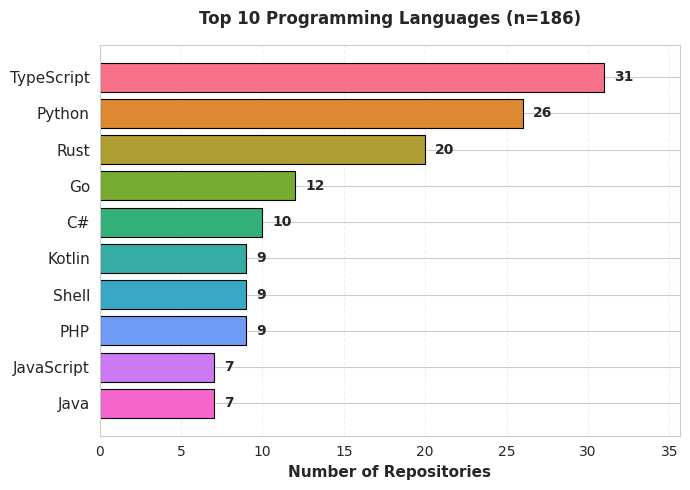


LANGUAGE ANALYSIS COMPLETE



In [34]:
# ============================================================================
# PROGRAMMING LANGUAGE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("TOP PROGRAMMING LANGUAGES IN ANALYZED REPOSITORIES")
print("="*80)

# Extract languages from repository metadata
language_counts = Counter()
repos_with_language = 0
repos_without_language = 0
missing_metadata = []

# Get list of analyzed repositories from ground truth
analyzed_repos = set(ground_truth.keys())

print(f"\nAnalyzing languages for {len(analyzed_repos)} repositories...")

for repo_name in analyzed_repos:
    if repo_name in repo_metadata:
        metadata = repo_metadata[repo_name]
        language = metadata.get('language')
        
        if language and language.strip():
            language_counts[language] += 1
            repos_with_language += 1
        else:
            repos_without_language += 1
    else:
        missing_metadata.append(repo_name)
        repos_without_language += 1

print(f"\n📊 Language Data Summary:")
print(f"   Total repositories: {len(analyzed_repos)}")
print(f"   With language data: {repos_with_language}")
print(f"   Without language data: {repos_without_language}")
print(f"   Missing from metadata: {len(missing_metadata)}")

if missing_metadata:
    print(f"\n⚠️  First 5 repositories missing from metadata:")
    for repo in list(missing_metadata)[:5]:
        print(f"      - {repo}")

# ============================================================================
# Display Top 10 Languages
# ============================================================================

print(f"\n{'='*80}")
print(f"LANGUAGE STATISTICS")
print(f"{'='*80}")

print(f"\nTotal unique languages: {len(language_counts)}")
print(f"\nTop 10 Programming Languages:")
print(f"{'Rank':<6} {'Language':<20} {'Count':<8} {'Percentage':<10}")
print("-" * 50)

top_10_languages = language_counts.most_common(10)
for rank, (language, count) in enumerate(top_10_languages, 1):
    percentage = (count / repos_with_language) * 100
    print(f"{rank:<6} {language:<20} {count:<8} {percentage:>6.2f}%")

# ============================================================================
# Visualization
# ============================================================================

print(f"\n{'='*80}")
print("GENERATING VISUALIZATION")
print(f"{'='*80}")

if top_10_languages:
    # Extract data
    languages = [lang for lang, count in top_10_languages]
    counts = [count for lang, count in top_10_languages]
    
    # Create figure (IEEE single-column format)
    fig, ax = plt.subplots(figsize=(7, 5))
    
    # Create horizontal bar chart
    colors = sns.color_palette("husl", len(languages))
    bars = ax.barh(range(len(languages)), counts, color=colors, edgecolor='black', linewidth=0.8)
    
    # Customize
    ax.set_yticks(range(len(languages)))
    ax.set_yticklabels(languages, fontsize=11)
    ax.set_xlabel('Number of Repositories', fontsize=11, fontweight='bold')
    ax.set_title(f'Top 10 Programming Languages (n={repos_with_language})',
                 fontsize=12, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()
    
    # Add value labels on bars
    for i, (bar, count) in enumerate(zip(bars, counts)):
        width = bar.get_width()
        ax.text(width + max(counts) * 0.02, bar.get_y() + bar.get_height()/2,
                f'{count}',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    # Set x-axis limit to make room for labels
    ax.set_xlim(0, max(counts) * 1.15)
    
    plt.tight_layout()
    
    # Save
    output_path = Path(CONFIG['paper_figures_dir']) / 'top_10_languages.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ Figure saved to: {output_path}")
    
    plt.show()
else:
    print("\n⚠️  No language data available to visualize")

print(f"\n{'='*80}")
print("LANGUAGE ANALYSIS COMPLETE")
print(f"{'='*80}\n")


REPOSITORY SIZE METRICS

Extracting size metrics for 190 repositories...

📊 Size Data Summary:
   Total repositories: 190
   With size data: 189
   Without size data: 1

REPOSITORY SIZE STATISTICS

Size in MB (GitHub reported):
   Mean:      22.86 MB
   Median:    13.80 MB
   Std Dev:   25.39 MB
   Min:       0.14 MB
   Max:       95.66 MB
   25th %ile: 2.70 MB
   75th %ile: 32.85 MB

Size Distribution:
   Small (<1 MB):         20 (10.6%)
   Medium (1-10 MB):      63 (33.3%)
   Large (10-100 MB):    106 (56.1%)
   Very Large (>100 MB):   0 (0.0%)

TOP 10 LARGEST REPOSITORIES

Rank   Repository                                         Size         Language       
------------------------------------------------------------------------------------------
1      online-go/online-go.com                            95.66 MB     TypeScript     
2      http4s/http4s                                      95.30 MB     Scala          
3      civictheme/monorepo-drupal                         90.89

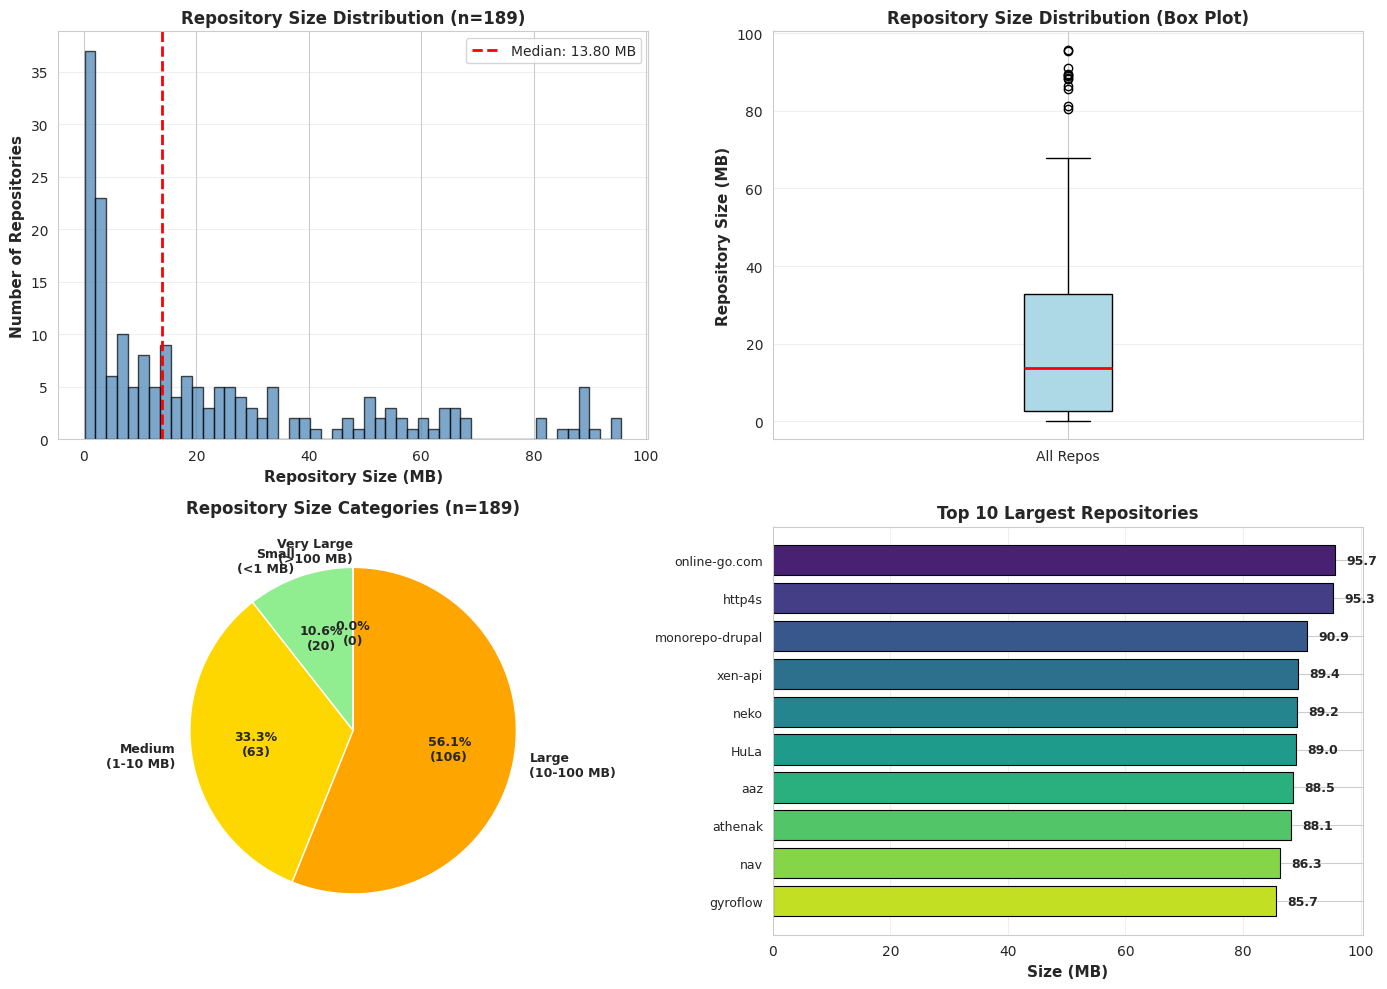


REPOSITORY SIZE ANALYSIS COMPLETE


NOTE: GitHub's 'size' metric represents the repository size in KB.
This includes all files tracked by Git but may not include build artifacts or
files excluded by .gitignore. It does NOT directly measure lines of code.

For accurate LOC/file count, you would need to analyze the cloned repositories directly.


In [35]:
# ============================================================================
# REPOSITORY SIZE METRICS ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("REPOSITORY SIZE METRICS")
print("="*80)

# Extract size metrics from repository metadata
size_data = []
repos_with_size = 0
repos_without_size = 0

# Get list of analyzed repositories from ground truth
analyzed_repos = set(ground_truth.keys())

print(f"\nExtracting size metrics for {len(analyzed_repos)} repositories...")

for repo_name in analyzed_repos:
    if repo_name in repo_metadata:
        metadata = repo_metadata[repo_name]
        
        # GitHub API provides 'size' in KB
        size_kb = metadata.get('size', None)
        
        if size_kb is not None:
            size_data.append({
                'repo': repo_name,
                'size_kb': size_kb,
                'size_mb': size_kb / 1024,
                'language': metadata.get('language', 'Unknown')
            })
            repos_with_size += 1
        else:
            repos_without_size += 1
    else:
        repos_without_size += 1

print(f"\n📊 Size Data Summary:")
print(f"   Total repositories: {len(analyzed_repos)}")
print(f"   With size data: {repos_with_size}")
print(f"   Without size data: {repos_without_size}")

# ============================================================================
# Statistical Summary
# ============================================================================

if size_data:
    import numpy as np
    
    sizes_kb = [d['size_kb'] for d in size_data]
    sizes_mb = [d['size_mb'] for d in size_data]
    
    print(f"\n{'='*80}")
    print(f"REPOSITORY SIZE STATISTICS")
    print(f"{'='*80}")
    
    print(f"\nSize in MB (GitHub reported):")
    print(f"   Mean:      {np.mean(sizes_mb):.2f} MB")
    print(f"   Median:    {np.median(sizes_mb):.2f} MB")
    print(f"   Std Dev:   {np.std(sizes_mb):.2f} MB")
    print(f"   Min:       {np.min(sizes_mb):.2f} MB")
    print(f"   Max:       {np.max(sizes_mb):.2f} MB")
    print(f"   25th %ile: {np.percentile(sizes_mb, 25):.2f} MB")
    print(f"   75th %ile: {np.percentile(sizes_mb, 75):.2f} MB")
    
    # Categorize by size
    small = sum(1 for s in sizes_mb if s < 1)
    medium = sum(1 for s in sizes_mb if 1 <= s < 10)
    large = sum(1 for s in sizes_mb if 10 <= s < 100)
    very_large = sum(1 for s in sizes_mb if s >= 100)
    
    print(f"\nSize Distribution:")
    print(f"   Small (<1 MB):        {small:3d} ({small/len(sizes_mb)*100:.1f}%)")
    print(f"   Medium (1-10 MB):     {medium:3d} ({medium/len(sizes_mb)*100:.1f}%)")
    print(f"   Large (10-100 MB):    {large:3d} ({large/len(sizes_mb)*100:.1f}%)")
    print(f"   Very Large (>100 MB): {very_large:3d} ({very_large/len(sizes_mb)*100:.1f}%)")
    
    # Top 10 largest repositories
    print(f"\n{'='*80}")
    print(f"TOP 10 LARGEST REPOSITORIES")
    print(f"{'='*80}")
    
    sorted_repos = sorted(size_data, key=lambda x: x['size_mb'], reverse=True)[:10]
    print(f"\n{'Rank':<6} {'Repository':<50} {'Size':<12} {'Language':<15}")
    print("-" * 90)
    for rank, repo in enumerate(sorted_repos, 1):
        size_str = f"{repo['size_mb']:.2f} MB"
        print(f"{rank:<6} {repo['repo']:<50} {size_str:<12} {repo['language']:<15}")
    
    # ========================================================================
    # Visualizations
    # ========================================================================
    
    print(f"\n{'='*80}")
    print("GENERATING VISUALIZATIONS")
    print(f"{'='*80}")
    
    # Create 2x2 subplot figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Distribution histogram (log scale)
    ax1 = axes[0, 0]
    ax1.hist(sizes_mb, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Repository Size (MB)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Number of Repositories', fontsize=11, fontweight='bold')
    ax1.set_title(f'Repository Size Distribution (n={len(sizes_mb)})', 
                  fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    ax1.axvline(np.median(sizes_mb), color='red', linestyle='--', linewidth=2, 
                label=f'Median: {np.median(sizes_mb):.2f} MB')
    ax1.legend()
    
    # 2. Box plot
    ax2 = axes[0, 1]
    bp = ax2.boxplot(sizes_mb, vert=True, patch_artist=True, 
                     boxprops=dict(facecolor='lightblue', edgecolor='black'),
                     medianprops=dict(color='red', linewidth=2))
    ax2.set_ylabel('Repository Size (MB)', fontsize=11, fontweight='bold')
    ax2.set_title('Repository Size Distribution (Box Plot)', 
                  fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_xticklabels(['All Repos'])
    
    # 3. Size categories pie chart
    ax3 = axes[1, 0]
    categories = ['Small\n(<1 MB)', 'Medium\n(1-10 MB)', 
                  'Large\n(10-100 MB)', 'Very Large\n(>100 MB)']
    sizes_cat = [small, medium, large, very_large]
    colors_cat = ['#90EE90', '#FFD700', '#FFA500', '#FF6347']
    
    wedges, texts, autotexts = ax3.pie(sizes_cat, labels=categories, colors=colors_cat,
                                        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(sizes_cat))})',
                                        startangle=90, textprops={'fontsize': 9, 'fontweight': 'bold'})
    ax3.set_title(f'Repository Size Categories (n={len(sizes_mb)})', 
                  fontsize=12, fontweight='bold', pad=10)
    
    # 4. Top 10 largest repositories
    ax4 = axes[1, 1]
    top_10_repos = sorted_repos[:10]
    repo_names = [r['repo'].split('/')[-1][:25] for r in top_10_repos]  # Shorten names
    repo_sizes = [r['size_mb'] for r in top_10_repos]
    
    colors_bar = sns.color_palette('viridis', len(repo_names))
    bars = ax4.barh(range(len(repo_names)), repo_sizes, color=colors_bar, 
                    edgecolor='black', linewidth=0.8)
    ax4.set_yticks(range(len(repo_names)))
    ax4.set_yticklabels(repo_names, fontsize=9)
    ax4.set_xlabel('Size (MB)', fontsize=11, fontweight='bold')
    ax4.set_title('Top 10 Largest Repositories', fontsize=12, fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)
    ax4.invert_yaxis()
    
    # Add value labels
    for i, (bar, size) in enumerate(zip(bars, repo_sizes)):
        width = bar.get_width()
        ax4.text(width + max(repo_sizes) * 0.02, bar.get_y() + bar.get_height()/2,
                f'{size:.1f}',
                ha='left', va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure
    output_path = Path(CONFIG['paper_figures_dir']) / 'repository_size_metrics.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ Figure saved to: {output_path}")
    
    plt.show()
    
else:
    print("\n⚠️  No size data available")

print(f"\n{'='*80}")
print("REPOSITORY SIZE ANALYSIS COMPLETE")
print(f"{'='*80}\n")

print("\nNOTE: GitHub's 'size' metric represents the repository size in KB.")
print("This includes all files tracked by Git but may not include build artifacts or")
print("files excluded by .gitignore. It does NOT directly measure lines of code.")
print("\nFor accurate LOC/file count, you would need to analyze the cloned repositories directly.")


REPOSITORY POPULARITY AND MATURITY METRICS

Extracting popularity metrics for 190 repositories...
   Loaded full data for 2767 repositories

📊 Metrics Data Summary:
   Total repositories: 190
   With complete data: 189
   Without complete data: 1

POPULARITY AND MATURITY STATISTICS

Stars (GitHub popularity):
   Mean:      3132
   Median:    352
   Std Dev:   8223
   Min:       10
   Max:       78162
   25th %ile: 46
   75th %ile: 2433

Repository Age (years):
   Mean:      4.95 years
   Median:    3.96 years
   Std Dev:   3.65 years
   Min:       0.84 years
   Max:       15.36 years
   25th %ile: 1.86 years
   75th %ile: 7.37 years

Contributors (unique usernames from JSONL):
   Mean:      1.7
   Median:    1.0
   Std Dev:   1.2
   Min:       1
   Max:       8
   25th %ile: 1.0
   75th %ile: 2.0

Stars Distribution:
   Low (<100):            69 (36.5%)
   Medium (100-1K):       52 (27.5%)
   High (1K-10K):         53 (28.0%)
   Very High (>10K):      15 (7.9%)

Age Distribution:
   N

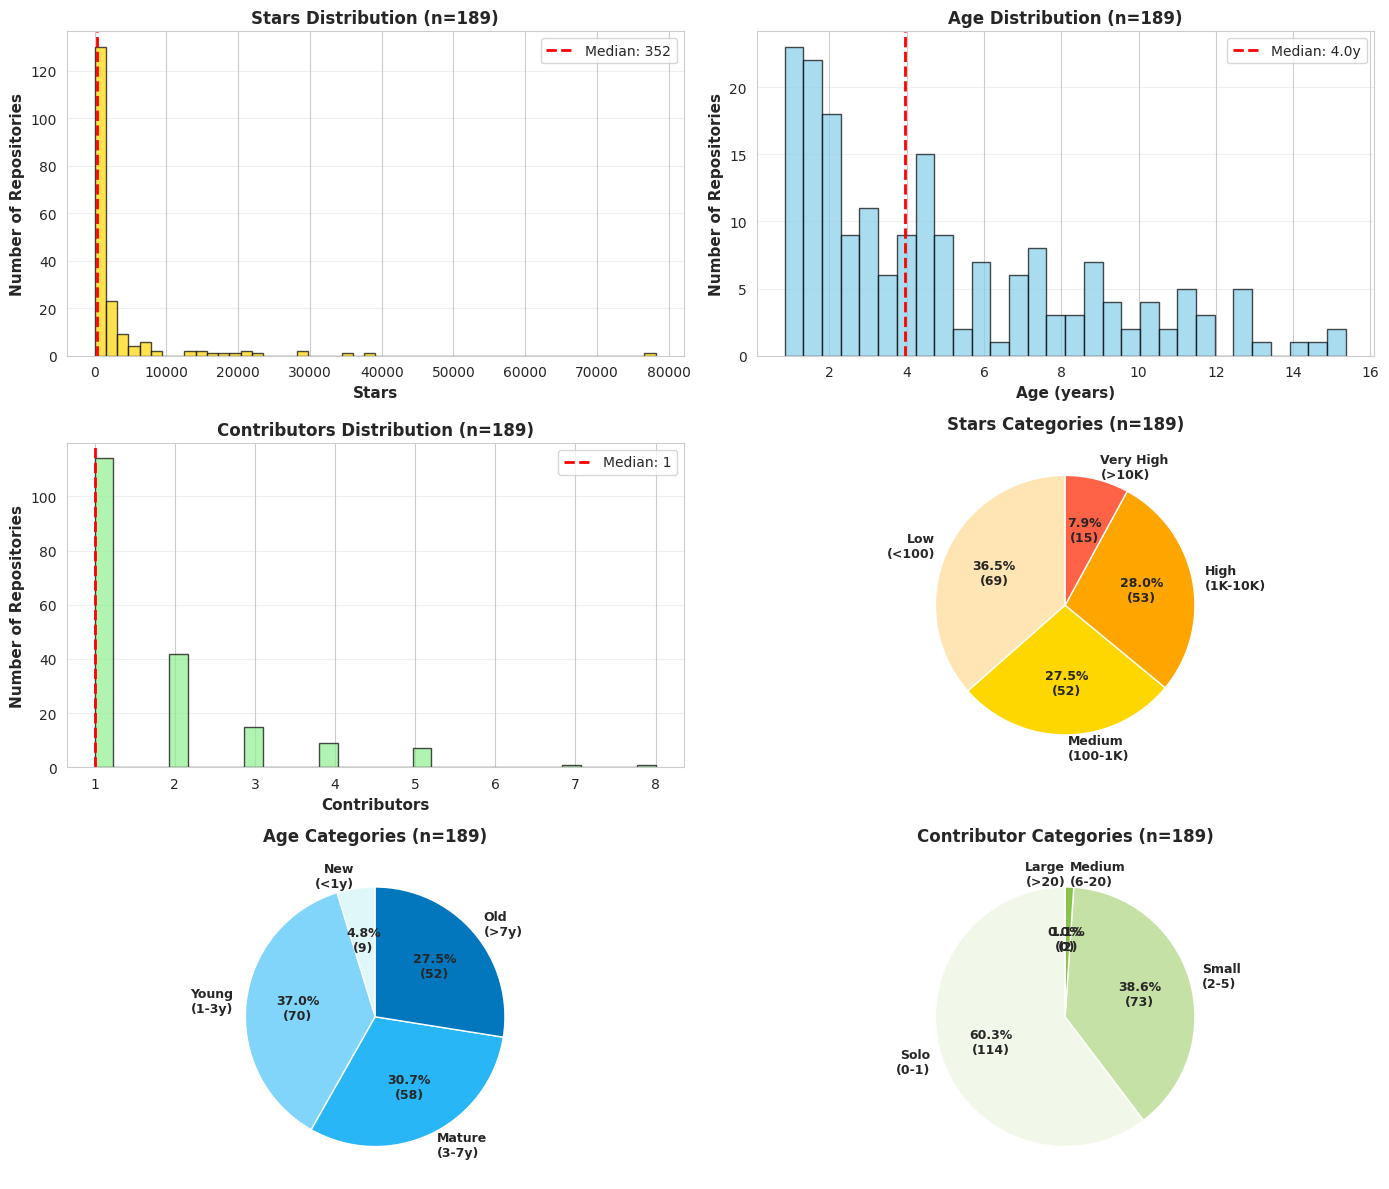


POPULARITY AND MATURITY ANALYSIS COMPLETE



In [36]:
# ============================================================================
# REPOSITORY POPULARITY AND MATURITY METRICS
# ============================================================================

print("\n" + "="*80)
print("REPOSITORY POPULARITY AND MATURITY METRICS")
print("="*80)

from datetime import datetime

# Extract metrics from repository metadata
repo_metrics = []
repos_with_data = 0
repos_without_data = 0

# Get list of analyzed repositories from ground truth
analyzed_repos = set(ground_truth.keys())

print(f"\nExtracting popularity metrics for {len(analyzed_repos)} repositories...")

# Re-load JSONL files to get contributors_data
repo_full_data = {}
for jsonl_path in CONFIG['repo_metadata_files']:
    if not Path(jsonl_path).exists():
        continue
    
    with open(jsonl_path, 'r') as f:
        for line in f:
            if line.strip():
                try:
                    data = json.loads(line)
                    full_name = data.get('metadata', {}).get('full_name', '')
                    if full_name:
                        repo_full_data[full_name] = data
                except:
                    continue

print(f"   Loaded full data for {len(repo_full_data)} repositories")

for repo_name in analyzed_repos:
    if repo_name in repo_full_data:
        full_data = repo_full_data[repo_name]
        metadata = full_data.get('metadata', {})
        
        # Extract stars
        stars = metadata.get('stargazers_count', None)
        
        # Extract age (calculate from created_at)
        created_at = metadata.get('created_at', None)
        age_days = None
        age_years = None
        if created_at:
            try:
                created_date = datetime.strptime(created_at, '%Y-%m-%dT%H:%M:%SZ')
                now = datetime.now()
                age_days = (now - created_date).days
                age_years = age_days / 365.25
            except:
                pass
        
        # Extract contributors from contributors_data
        contributors_data = full_data.get('contributors_data', {})
        num_contributors = len(contributors_data) if contributors_data else 0
        
        if stars is not None and age_days is not None:
            repo_metrics.append({
                'repo': repo_name,
                'stars': stars,
                'age_days': age_days,
                'age_years': age_years,
                'created_at': created_at,
                'language': metadata.get('language', 'Unknown'),
                'forks': metadata.get('forks_count', 0),
                'watchers': metadata.get('watchers_count', 0),
                'open_issues': metadata.get('open_issues_count', 0),
                'contributors': num_contributors
            })
            repos_with_data += 1
        else:
            repos_without_data += 1
    else:
        repos_without_data += 1

print(f"\n📊 Metrics Data Summary:")
print(f"   Total repositories: {len(analyzed_repos)}")
print(f"   With complete data: {repos_with_data}")
print(f"   Without complete data: {repos_without_data}")

# ============================================================================
# Statistical Summary
# ============================================================================

if repo_metrics:
    import numpy as np
    
    stars = [d['stars'] for d in repo_metrics]
    ages = [d['age_years'] for d in repo_metrics]
    contributors = [d['contributors'] for d in repo_metrics]
    
    print(f"\n{'='*80}")
    print(f"POPULARITY AND MATURITY STATISTICS")
    print(f"{'='*80}")
    
    # Stars Statistics
    print(f"\nStars (GitHub popularity):")
    print(f"   Mean:      {np.mean(stars):.0f}")
    print(f"   Median:    {np.median(stars):.0f}")
    print(f"   Std Dev:   {np.std(stars):.0f}")
    print(f"   Min:       {np.min(stars):.0f}")
    print(f"   Max:       {np.max(stars):.0f}")
    print(f"   25th %ile: {np.percentile(stars, 25):.0f}")
    print(f"   75th %ile: {np.percentile(stars, 75):.0f}")
    
    # Age Statistics
    print(f"\nRepository Age (years):")
    print(f"   Mean:      {np.mean(ages):.2f} years")
    print(f"   Median:    {np.median(ages):.2f} years")
    print(f"   Std Dev:   {np.std(ages):.2f} years")
    print(f"   Min:       {np.min(ages):.2f} years")
    print(f"   Max:       {np.max(ages):.2f} years")
    print(f"   25th %ile: {np.percentile(ages, 25):.2f} years")
    print(f"   75th %ile: {np.percentile(ages, 75):.2f} years")
    
    # Contributors Statistics
    print(f"\nContributors (unique usernames from JSONL):")
    print(f"   Mean:      {np.mean(contributors):.1f}")
    print(f"   Median:    {np.median(contributors):.1f}")
    print(f"   Std Dev:   {np.std(contributors):.1f}")
    print(f"   Min:       {np.min(contributors):.0f}")
    print(f"   Max:       {np.max(contributors):.0f}")
    print(f"   25th %ile: {np.percentile(contributors, 25):.1f}")
    print(f"   75th %ile: {np.percentile(contributors, 75):.1f}")
    
    # Categorize repositories
    # Stars categories
    stars_low = sum(1 for s in stars if s < 100)
    stars_medium = sum(1 for s in stars if 100 <= s < 1000)
    stars_high = sum(1 for s in stars if 1000 <= s < 10000)
    stars_very_high = sum(1 for s in stars if s >= 10000)
    
    print(f"\nStars Distribution:")
    print(f"   Low (<100):           {stars_low:3d} ({stars_low/len(stars)*100:.1f}%)")
    print(f"   Medium (100-1K):      {stars_medium:3d} ({stars_medium/len(stars)*100:.1f}%)")
    print(f"   High (1K-10K):        {stars_high:3d} ({stars_high/len(stars)*100:.1f}%)")
    print(f"   Very High (>10K):     {stars_very_high:3d} ({stars_very_high/len(stars)*100:.1f}%)")
    
    # Age categories
    age_new = sum(1 for a in ages if a < 1)
    age_young = sum(1 for a in ages if 1 <= a < 3)
    age_mature = sum(1 for a in ages if 3 <= a < 7)
    age_old = sum(1 for a in ages if a >= 7)
    
    print(f"\nAge Distribution:")
    print(f"   New (<1 year):        {age_new:3d} ({age_new/len(ages)*100:.1f}%)")
    print(f"   Young (1-3 years):    {age_young:3d} ({age_young/len(ages)*100:.1f}%)")
    print(f"   Mature (3-7 years):   {age_mature:3d} ({age_mature/len(ages)*100:.1f}%)")
    print(f"   Old (>7 years):       {age_old:3d} ({age_old/len(ages)*100:.1f}%)")
    
    # Contributors categories
    contrib_solo = sum(1 for c in contributors if c <= 1)
    contrib_small = sum(1 for c in contributors if 2 <= c <= 5)
    contrib_medium = sum(1 for c in contributors if 6 <= c <= 20)
    contrib_large = sum(1 for c in contributors if c > 20)
    
    print(f"\nContributor Distribution:")
    print(f"   Solo (0-1):           {contrib_solo:3d} ({contrib_solo/len(contributors)*100:.1f}%)")
    print(f"   Small Team (2-5):     {contrib_small:3d} ({contrib_small/len(contributors)*100:.1f}%)")
    print(f"   Medium Team (6-20):   {contrib_medium:3d} ({contrib_medium/len(contributors)*100:.1f}%)")
    print(f"   Large Team (>20):     {contrib_large:3d} ({contrib_large/len(contributors)*100:.1f}%)")
    
    # ========================================================================
    # Top 10 Lists
    # ========================================================================
    
    print(f"\n{'='*80}")
    print(f"TOP 10 MOST POPULAR REPOSITORIES (by stars)")
    print(f"{'='*80}")
    
    sorted_by_stars = sorted(repo_metrics, key=lambda x: x['stars'], reverse=True)[:10]
    print(f"\n{'Rank':<6} {'Repository':<45} {'Stars':<10} {'Age':<8} {'Contributors'}")
    print("-" * 90)
    for rank, repo in enumerate(sorted_by_stars, 1):
        print(f"{rank:<6} {repo['repo']:<45} {repo['stars']:<10} {repo['age_years']:.1f}y    {repo['contributors']}")
    
    print(f"\n{'='*80}")
    print(f"TOP 10 OLDEST REPOSITORIES")
    print(f"{'='*80}")
    
    sorted_by_age = sorted(repo_metrics, key=lambda x: x['age_years'], reverse=True)[:10]
    print(f"\n{'Rank':<6} {'Repository':<45} {'Age':<15} {'Stars':<10} {'Contributors'}")
    print("-" * 90)
    for rank, repo in enumerate(sorted_by_age, 1):
        print(f"{rank:<6} {repo['repo']:<45} {repo['age_years']:.1f} years    {repo['stars']:<10} {repo['contributors']}")
    
    print(f"\n{'='*80}")
    print(f"TOP 10 MOST CONTRIBUTED REPOSITORIES")
    print(f"{'='*80}")
    
    sorted_by_contrib = sorted(repo_metrics, key=lambda x: x['contributors'], reverse=True)[:10]
    print(f"\n{'Rank':<6} {'Repository':<45} {'Contributors':<15} {'Stars':<10} {'Age'}")
    print("-" * 90)
    for rank, repo in enumerate(sorted_by_contrib, 1):
        print(f"{rank:<6} {repo['repo']:<45} {repo['contributors']:<15} {repo['stars']:<10} {repo['age_years']:.1f}y")
    
    # ========================================================================
    # Visualizations
    # ========================================================================
    
    print(f"\n{'='*80}")
    print("GENERATING VISUALIZATIONS")
    print(f"{'='*80}")
    
    # Create 3x2 subplot figure
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    
    # 1. Stars distribution (histogram)
    ax1 = axes[0, 0]
    ax1.hist(stars, bins=50, color='gold', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Stars', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Number of Repositories', fontsize=11, fontweight='bold')
    ax1.set_title(f'Stars Distribution (n={len(stars)})', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    ax1.axvline(np.median(stars), color='red', linestyle='--', linewidth=2,
                label=f'Median: {np.median(stars):.0f}')
    ax1.legend()
    
    # 2. Age distribution (histogram)
    ax2 = axes[0, 1]
    ax2.hist(ages, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Age (years)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Number of Repositories', fontsize=11, fontweight='bold')
    ax2.set_title(f'Age Distribution (n={len(ages)})', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    ax2.axvline(np.median(ages), color='red', linestyle='--', linewidth=2,
                label=f'Median: {np.median(ages):.1f}y')
    ax2.legend()
    
    # 3. Contributors distribution (histogram)
    ax3 = axes[1, 0]
    ax3.hist(contributors, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
    ax3.set_xlabel('Contributors', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Number of Repositories', fontsize=11, fontweight='bold')
    ax3.set_title(f'Contributors Distribution (n={len(contributors)})', 
                  fontsize=12, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    ax3.axvline(np.median(contributors), color='red', linestyle='--', linewidth=2,
                label=f'Median: {np.median(contributors):.0f}')
    ax3.legend()
    
    # 4. Stars categories pie chart
    ax4 = axes[1, 1]
    categories_stars = ['Low\n(<100)', 'Medium\n(100-1K)', 'High\n(1K-10K)', 'Very High\n(>10K)']
    sizes_stars = [stars_low, stars_medium, stars_high, stars_very_high]
    colors_stars = ['#FFE5B4', '#FFD700', '#FFA500', '#FF6347']
    
    wedges, texts, autotexts = ax4.pie(sizes_stars, labels=categories_stars, colors=colors_stars,
                                        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(sizes_stars))})',
                                        startangle=90, textprops={'fontsize': 9, 'fontweight': 'bold'})
    ax4.set_title(f'Stars Categories (n={len(stars)})', fontsize=12, fontweight='bold', pad=10)
    
    # 5. Age categories pie chart
    ax5 = axes[2, 0]
    categories_age = ['New\n(<1y)', 'Young\n(1-3y)', 'Mature\n(3-7y)', 'Old\n(>7y)']
    sizes_age = [age_new, age_young, age_mature, age_old]
    colors_age = ['#E0F7FA', '#81D4FA', '#29B6F6', '#0277BD']
    
    wedges, texts, autotexts = ax5.pie(sizes_age, labels=categories_age, colors=colors_age,
                                        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(sizes_age))})',
                                        startangle=90, textprops={'fontsize': 9, 'fontweight': 'bold'})
    ax5.set_title(f'Age Categories (n={len(ages)})', fontsize=12, fontweight='bold', pad=10)
    
    # 6. Contributors categories pie chart
    ax6 = axes[2, 1]
    categories_contrib = ['Solo\n(0-1)', 'Small\n(2-5)', 'Medium\n(6-20)', 'Large\n(>20)']
    sizes_contrib = [contrib_solo, contrib_small, contrib_medium, contrib_large]
    colors_contrib = ['#F1F8E9', '#C5E1A5', '#8BC34A', '#558B2F']
    
    wedges, texts, autotexts = ax6.pie(sizes_contrib, labels=categories_contrib, colors=colors_contrib,
                                        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(sizes_contrib))})',
                                        startangle=90, textprops={'fontsize': 9, 'fontweight': 'bold'})
    ax6.set_title(f'Contributor Categories (n={len(contributors)})', 
                  fontsize=12, fontweight='bold', pad=10)
    
    plt.tight_layout()
    
    # Save figure
    output_path = Path(CONFIG['paper_figures_dir']) / 'repository_popularity_maturity.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ Figure saved to: {output_path}")
    
    plt.show()
    
else:
    print("\n⚠️  No metrics data available")

print(f"\n{'='*80}")
print("POPULARITY AND MATURITY ANALYSIS COMPLETE")
print(f"{'='*80}\n")

In [37]:
# ============================================================================
# CELL: Per-Repository Detection Effectiveness Analysis
# ============================================================================
# This cell analyzes detection effectiveness at the repository level,
# showing which repos had better/worse pattern detection results compared
# to ground truth (survey responses from maintainers).
#
# IMPORTANT: A "successful detection" means MicroPAD's output MATCHES the survey:
#   - If maintainers say a pattern is PRESENT and MicroPAD detects it → SUCCESS (TP)
#   - If maintainers say a pattern is ABSENT and MicroPAD does NOT detect it → SUCCESS (TN)
#   - If maintainers say a pattern is ABSENT but MicroPAD detects it → FAILURE (FP)
#   - If maintainers say a pattern is PRESENT but MicroPAD misses it → FAILURE (FN)
#
# Therefore:
#   - A repo with 0 patterns where MicroPAD finds 0 = 100% accuracy (9 TN)
#   - A repo with 9 patterns where MicroPAD finds all 9 = 100% accuracy (9 TP)
#   - A repo with 1 pattern where MicroPAD finds only that 1 = 100% accuracy (1 TP + 8 TN)

print("=" * 80)
print("PER-REPOSITORY DETECTION EFFECTIVENESS ANALYSIS")
print("=" * 80)
print("\nNOTE: Success = MicroPAD matches survey responses (both detecting present")
print("      patterns AND correctly not detecting absent patterns)")

# Load all reports and calculate per-repo metrics
all_reports = load_reports_by_criteria(CONFIG['results_base_dir'])

if len(all_reports) == 0:
    print("\n⚠️  No reports found.")
else:
    # Calculate per-repository metrics
    repo_metrics = calculate_metrics_for_reports(all_reports, ground_truth)
    
    # Add additional columns for clarity
    repo_metrics['total_patterns'] = repo_metrics['tp'] + repo_metrics['fp'] + repo_metrics['tn'] + repo_metrics['fn']
    repo_metrics['correct'] = repo_metrics['tp'] + repo_metrics['tn']
    repo_metrics['incorrect'] = repo_metrics['fp'] + repo_metrics['fn']
    
    # Sort by accuracy (best performing first)
    repo_metrics_sorted = repo_metrics.sort_values(by=['accuracy', 'f1'], ascending=[False, False])
    
    print(f"\n📊 Total Repositories Analyzed: {len(repo_metrics_sorted)}")
    print(f"   Total Patterns per Repository: 9")
    
    # =========================================================================
    # Summary Statistics
    # =========================================================================
    print(f"\n{'='*80}")
    print("DETECTION ACCURACY DISTRIBUTION")
    print("(Accuracy = matches with survey / total patterns)")
    print(f"{'='*80}")
    
    print(f"\n   Mean Accuracy:   {repo_metrics_sorted['accuracy'].mean():.4f}")
    print(f"   Median Accuracy: {repo_metrics_sorted['accuracy'].median():.4f}")
    print(f"   Std Accuracy:    {repo_metrics_sorted['accuracy'].std():.4f}")
    print(f"   Min Accuracy:    {repo_metrics_sorted['accuracy'].min():.4f}")
    print(f"   Max Accuracy:    {repo_metrics_sorted['accuracy'].max():.4f}")
    
    # Accuracy buckets
    perfect = (repo_metrics_sorted['accuracy'] == 1.0).sum()
    high = ((repo_metrics_sorted['accuracy'] >= 0.8) & (repo_metrics_sorted['accuracy'] < 1.0)).sum()
    medium = ((repo_metrics_sorted['accuracy'] >= 0.6) & (repo_metrics_sorted['accuracy'] < 0.8)).sum()
    low = (repo_metrics_sorted['accuracy'] < 0.6).sum()
    
    print(f"\n   Accuracy Buckets (how well MicroPAD matched the survey):")
    print(f"     Perfect (100%):    {perfect:3d} repos ({100*perfect/len(repo_metrics_sorted):.1f}%) - All 9 patterns match survey")
    print(f"     High (80-99%):     {high:3d} repos ({100*high/len(repo_metrics_sorted):.1f}%) - 7-8 patterns match survey")
    print(f"     Medium (60-79%):   {medium:3d} repos ({100*medium/len(repo_metrics_sorted):.1f}%) - 5-7 patterns match survey")
    print(f"     Low (<60%):        {low:3d} repos ({100*low/len(repo_metrics_sorted):.1f}%) - <5 patterns match survey")

    # =========================================================================
    # Top 20 Best Performing Repositories
    # =========================================================================
    print(f"\n{'='*80}")
    print("TOP 20 BEST PERFORMING REPOSITORIES (highest match with survey)")
    print(f"{'='*80}")
    print("\nTP = Correctly detected present patterns")
    print("TN = Correctly did NOT detect absent patterns")
    print("FP = Wrongly detected absent patterns")
    print("FN = Missed present patterns")
    print("Score = Correct matches / 9 total patterns")
    
    print(f"\n{'Rank':<6}{'Repository':<50}{'Acc':<8}{'F1':<8}{'TP':<5}{'TN':<5}{'FP':<5}{'FN':<5}{'Score'}")
    print("-" * 100)
    
    for rank, (idx, row) in enumerate(repo_metrics_sorted.head(20).iterrows(), 1):
        score_str = f"{int(row['correct'])}/{int(row['total_patterns'])}"
        print(f"{rank:<6}{row['repository'][:48]:<50}{row['accuracy']:.4f}  {row['f1']:.4f}  {int(row['tp']):<5}{int(row['tn']):<5}{int(row['fp']):<5}{int(row['fn']):<5}{score_str}")

    # =========================================================================
    # Bottom 20 Worst Performing Repositories
    # =========================================================================
    print(f"\n{'='*80}")
    print("BOTTOM 20 WORST PERFORMING REPOSITORIES (lowest match with survey)")
    print(f"{'='*80}")
    
    print(f"\n{'Rank':<6}{'Repository':<50}{'Acc':<8}{'F1':<8}{'TP':<5}{'TN':<5}{'FP':<5}{'FN':<5}{'Score'}")
    print("-" * 100)
    
    worst_repos = repo_metrics_sorted.tail(20).iloc[::-1]  # Reverse to show worst first
    for rank, (idx, row) in enumerate(worst_repos.iterrows(), 1):
        score_str = f"{int(row['correct'])}/{int(row['total_patterns'])}"
        print(f"{rank:<6}{row['repository'][:48]:<50}{row['accuracy']:.4f}  {row['f1']:.4f}  {int(row['tp']):<5}{int(row['tn']):<5}{int(row['fp']):<5}{int(row['fn']):<5}{score_str}")

    # =========================================================================
    # Detailed Pattern Analysis per Repository
    # =========================================================================
    print(f"\n{'='*80}")
    print("DETAILED PATTERN DETECTION BREAKDOWN PER REPOSITORY")
    print(f"{'='*80}")
    print("\nLegend:")
    print("  ✓ TP = True Positive: Survey says PRESENT, MicroPAD DETECTED (correct)")
    print("  ✓ TN = True Negative: Survey says ABSENT, MicroPAD did NOT detect (correct)")
    print("  ✗ FP = False Positive: Survey says ABSENT, but MicroPAD DETECTED (wrong)")
    print("  ✗ FN = False Negative: Survey says PRESENT, but MicroPAD MISSED (wrong)")
    
    # Build detailed breakdown for each repository
    detailed_results = []
    
    for report in all_reports:
        repo_name = report.get('summary', {}).get('repository_name', '')
        if not repo_name or repo_name not in ground_truth:
            continue
        
        detections = extract_detections_from_report(report)
        repo_gt = ground_truth[repo_name]['patterns']
        
        tp_patterns = []
        tn_patterns = []
        fp_patterns = []
        fn_patterns = []
        
        for pattern in repo_gt.keys():
            gt_value = repo_gt.get(pattern, False)
            detected = detections.get(pattern, False)
            
            if gt_value and detected:
                tp_patterns.append(pattern)
            elif not gt_value and not detected:
                tn_patterns.append(pattern)
            elif not gt_value and detected:
                fp_patterns.append(pattern)
            elif gt_value and not detected:
                fn_patterns.append(pattern)
        
        accuracy = (len(tp_patterns) + len(tn_patterns)) / 9
        patterns_in_survey = len(tp_patterns) + len(fn_patterns)  # How many patterns the survey says exist
        
        detailed_results.append({
            'repository': repo_name,
            'accuracy': accuracy,
            'patterns_in_survey': patterns_in_survey,
            'tp_count': len(tp_patterns),
            'tn_count': len(tn_patterns),
            'fp_count': len(fp_patterns),
            'fn_count': len(fn_patterns),
            'tp_patterns': tp_patterns,
            'tn_patterns': tn_patterns,
            'fp_patterns': fp_patterns,
            'fn_patterns': fn_patterns
        })
    
    # Sort by accuracy
    detailed_results.sort(key=lambda x: x['accuracy'], reverse=True)
    
    # Print detailed breakdown for all repositories
    print(f"\n{'='*80}")
    print("COMPLETE REPOSITORY RANKING WITH PATTERN DETAILS")
    print(f"{'='*80}\n")
    
    for rank, result in enumerate(detailed_results, 1):
        correct = result['tp_count'] + result['tn_count']
        print(f"\n{'─'*80}")
        print(f"#{rank:3d} | {result['repository']}")
        print(f"      Survey says: {result['patterns_in_survey']}/9 patterns present")
        print(f"      Accuracy: {result['accuracy']:.2%} ({correct}/9 decisions match survey)")
        print(f"      TP: {result['tp_count']}, TN: {result['tn_count']}, FP: {result['fp_count']}, FN: {result['fn_count']}")
        
        if result['tp_patterns']:
            print(f"      ✓ TRUE POSITIVES (survey=present, MicroPAD=detected):")
            for p in result['tp_patterns']:
                print(f"          - {p}")
        
        if result['tn_patterns']:
            print(f"      ✓ TRUE NEGATIVES (survey=absent, MicroPAD=not detected):")
            for p in result['tn_patterns']:
                print(f"          - {p}")
        
        if result['fp_patterns']:
            print(f"      ✗ FALSE POSITIVES (survey=absent, but MicroPAD detected):")
            for p in result['fp_patterns']:
                print(f"          - {p}")
        
        if result['fn_patterns']:
            print(f"      ✗ FALSE NEGATIVES (survey=present, but MicroPAD missed):")
            for p in result['fn_patterns']:
                print(f"          - {p}")

    # =========================================================================
    # Save Results to CSV
    # =========================================================================
    print(f"\n{'='*80}")
    print("SAVING RESULTS")
    print(f"{'='*80}")
    
    # Save summary table
    summary_df = repo_metrics_sorted[['repository', 'accuracy', 'f1', 'precision', 'recall', 
                                       'tp', 'tn', 'fp', 'fn', 'correct', 'incorrect']].copy()
    summary_df = summary_df.rename(columns={
        'repository': 'Repository',
        'accuracy': 'Accuracy',
        'f1': 'F1-Score',
        'precision': 'Precision',
        'recall': 'Recall',
        'tp': 'True Positives',
        'tn': 'True Negatives',
        'fp': 'False Positives',
        'fn': 'False Negatives',
        'correct': 'Correct Detections',
        'incorrect': 'Incorrect Detections'
    })
    
    output_path = Path(CONFIG['paper_tables_dir']) / 'per_repository_detection_effectiveness.csv'
    summary_df.to_csv(output_path, index=False)
    print(f"\n✅ Summary table saved to: {output_path}")
    
    # Save detailed breakdown as JSON for further analysis
    detailed_output_path = Path(CONFIG['paper_tables_dir']) / 'per_repository_pattern_details.json'
    with open(detailed_output_path, 'w') as f:
        json.dump(detailed_results, f, indent=2)
    print(f"✅ Detailed pattern breakdown saved to: {detailed_output_path}")

print(f"\n{'='*80}")
print("PER-REPOSITORY DETECTION ANALYSIS COMPLETE")
print(f"{'='*80}\n")

PER-REPOSITORY DETECTION EFFECTIVENESS ANALYSIS

NOTE: Success = MicroPAD matches survey responses (both detecting present
      patterns AND correctly not detecting absent patterns)
📂 Loading from: ../experiment_data/paper_evidence/detection_results
   Found 192 JSON files

✅ Loaded 192 reports from 192 repositories

📊 Total Repositories Analyzed: 192
   Total Patterns per Repository: 9

DETECTION ACCURACY DISTRIBUTION
(Accuracy = matches with survey / total patterns)

   Mean Accuracy:   0.7870
   Median Accuracy: 0.8889
   Std Accuracy:    0.2063
   Min Accuracy:    0.0000
   Max Accuracy:    1.0000

   Accuracy Buckets (how well MicroPAD matched the survey):
     Perfect (100%):     46 repos (24.0%) - All 9 patterns match survey
     High (80-99%):      51 repos (26.6%) - 7-8 patterns match survey
     Medium (60-79%):    59 repos (30.7%) - 5-7 patterns match survey
     Low (<60%):         36 repos (18.8%) - <5 patterns match survey

TOP 20 BEST PERFORMING REPOSITORIES (highest ma